# Women's Health AI — Fine-Tuning LLaMA 3.2 with QLoRA

**Author:** Nishant  
**Date:** 2026-04-11  
**Purpose:** Build a production-ready Google Colab workflow that fine-tunes `meta-llama/Llama-3.2-3B-Instruct` with QLoRA on a T4 GPU for women's health education.

This notebook prepares a compassionate, judgment-free assistant that can answer questions about periods, PMS, PCOS, endometriosis, contraception, discharge, STIs, vaginal infections, hormones, menopause, libido, pain during sex, pregnancy-related body changes, breast health, and other women's health topics.

It is designed for:
- people who want respectful, stigma-free answers about their bodies
- builders creating a health education assistant
- researchers prototyping a domain-adapted medical instruction model on low-cost hardware

Why this matters:
- many women delay care because of embarrassment or fear of judgment
- body-related questions are often dismissed, minimized, or answered vaguely online
- a carefully fine-tuned assistant can improve access to understandable educational information

> **Warning:** This model is for educational purposes, not a substitute for professional medical advice.  
> It should not diagnose, prescribe, or replace an evaluation by a qualified healthcare professional.


## Cell 2 — Install Dependencies

This cell installs the training stack with pinned versions selected for a Colab T4 QLoRA workflow. Output stays readable because the `pip` commands use quiet mode, but the notebook still prints package-version confirmation afterward so you can verify the environment.


In [1]:
%%javascript
// Better keep-alive — simulates real user activity
function keepAlive() {
    const now = new Date().toLocaleTimeString();

    // Method 1: Click anywhere on the document
    document.body.click();

    // Method 2: Scroll slightly and back
    window.scrollBy(0, 1);
    window.scrollBy(0, -1);

    // Method 3: Simulate mouse move event
    document.dispatchEvent(new MouseEvent('mousemove', {
        bubbles: true,
        cancelable: true,
        clientX: Math.random() * 100,
        clientY: Math.random() * 100
    }));

    // Method 4: Focus the window
    window.focus();

    console.log("✅ Keep-alive ping: " + now);
}

// Run every 30 seconds (more frequent than before)
const interval = setInterval(keepAlive, 30000);
console.log("🟢 Keep-alive started — pinging every 30 seconds");

<IPython.core.display.Javascript object>

In [2]:
!pip install "unsloth[colab] @ git+https://github.com/unslothai/unsloth.git"

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-g4kytqrb/unsloth_ed772f8716bd4b2ba53259b35742f2b9
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-g4kytqrb/unsloth_ed772f8716bd4b2ba53259b35742f2b9
  Resolved https://github.com/unslothai/unsloth.git to commit a5615426a56857983909b05016b3d985710e0015
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 32.6 MB/s eta 0:00:00


## Cell 3b — HuggingFace Authentication (Required for Llama 3.2)

⚠️ Llama 3.2 is a gated model. Before running this notebook you MUST:
1. Go to https://huggingface.co/meta-llama/Llama-3.2-3B-Instruct
2. Accept Meta's license agreement
3. Go to https://huggingface.co/settings/tokens and create a READ token
4. Paste it in the input box below


In [3]:
# Cell 3b: Hugging Face authentication for gated model access
from huggingface_hub import login, whoami
from google.colab import userdata
import os

# Try to load from Colab secrets first (recommended)
# In Colab: click the 🔑 key icon -> add secret named HF_TOKEN
try:
    hf_token = userdata.get("HF_TOKEN")
    print("✅ Found HF_TOKEN in Colab secrets")
except Exception:
    hf_token = None

# Fall back to manual input
if not hf_token:
    hf_token = input("🔑 Paste your HuggingFace token here (will not be shown): ").strip()

if not hf_token:
    raise ValueError("No HuggingFace token provided. Llama 3.2 cannot be downloaded without it.")

login(token=hf_token, add_to_git_credential=False)

try:
    user_info = whoami()
    print(f"✅ Logged in as: {user_info['name']}")
    print("   Make sure you have accepted the Llama 3.2 license at:")
    print("   https://huggingface.co/meta-llama/Llama-3.2-3B-Instruct")
except Exception as e:
    print(f"⚠️ Could not verify login: {e}")


## Cell 3 — GPU Check & Environment Info

This cell verifies that Colab is using a GPU runtime, checks whether the GPU is a T4 or better, and prints CUDA, RAM, and disk information so we can catch environment problems early.


In [4]:
# Cell 3: GPU check and environment diagnostics
import os
import platform
import shutil
import subprocess
import sys
from textwrap import indent

try:
    import torch
except ImportError:
    raise RuntimeError("PyTorch is not installed yet. Run the dependency install cell before this one.")

def bytes_to_gb(num_bytes: int) -> float:
    return round(num_bytes / (1024 ** 3), 2)

print("🔍 Checking Colab runtime...")
if not torch.cuda.is_available():
    raise EnvironmentError(
        "No GPU runtime detected. In Colab, go to Runtime > Change runtime type > GPU, then re-run this notebook."
    )

gpu_name = torch.cuda.get_device_name(0)
print(f"✅ GPU detected: {gpu_name}")

allowed_keywords = ["T4", "V100", "L4", "A10", "A100"]
assert any(keyword in gpu_name.upper() for keyword in allowed_keywords), (
    f"Expected a T4 or better GPU, but found: {gpu_name}. "
    "Switch to a stronger runtime before training."
)

print(f"🧠 Python version: {sys.version.split()[0]}")
print(f"💻 Platform: {platform.platform()}")

cuda_version = torch.version.cuda or "unknown"
print(f"⚙️ CUDA version reported by torch: {cuda_version}")

total_vram = torch.cuda.get_device_properties(0).total_memory
print(f"🎮 GPU VRAM: {bytes_to_gb(total_vram)} GB")

try:
    ram_info = os.popen("free -h").read().strip()
    print("🧾 System RAM:")
    print(indent(ram_info, prefix="   "))
except Exception as exc:
    print(f"⚠️ Could not read RAM information: {exc}")

total_disk, used_disk, free_disk = shutil.disk_usage("/")
print(f"💽 Disk total: {bytes_to_gb(total_disk)} GB")
print(f"💽 Disk used : {bytes_to_gb(used_disk)} GB")
print(f"💽 Disk free : {bytes_to_gb(free_disk)} GB")

try:
    nvidia_smi = subprocess.check_output(["nvidia-smi"], text=True)
    print("\n📊 nvidia-smi output:")
    print(indent(nvidia_smi, prefix="   "))
except Exception as exc:
    print(f"⚠️ Could not run nvidia-smi: {exc}")


🔍 Checking Colab runtime...
✅ GPU detected: Tesla T4
🧠 Python version: 3.12.13
💻 Platform: Linux-6.6.113+-x86_64-with-glibc2.35
⚙️ CUDA version reported by torch: 12.8
🎮 GPU VRAM: 14.56 GB
🧾 System RAM:
   total        used        free      shared  buff/cache   available
   Mem:            12Gi       1.0Gi       5.1Gi       3.0Mi       6.6Gi        11Gi
   Swap:             0B          0B          0B
💽 Disk total: 112.64 GB
💽 Disk used : 43.71 GB
💽 Disk free : 68.91 GB

📊 nvidia-smi output:
   Wed Apr 29 07:04:00 2026       
   +-----------------------------------------------------------------------------------------+
   | NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
   +-----------------------------------------+------------------------+----------------------+
   | GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
   | Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute

## Cell 4 — Imports

This cell gathers all imports in one place, organizes them by purpose, sets random seeds for reproducibility, and reduces logging noise before training starts.


In [5]:
import gc
import json
import logging
import math
import os
import random
import re
import shutil
import subprocess
import textwrap
import time
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from unsloth import FastLanguageModel, is_bfloat16_supported # Moved to top

from datasets import Dataset, DatasetDict, concatenate_datasets, load_dataset
from huggingface_hub import HfApi, login
from tqdm.auto import tqdm
from trl import SFTConfig, SFTTrainer


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO)
logging.getLogger("transformers").setLevel(logging.WARNING)
logging.getLogger("datasets").setLevel(logging.WARNING)
logging.getLogger("trl").setLevel(logging.INFO)

print("✅ Imports ready")
print(f"🎯 Reproducibility seed set to {SEED}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
✅ Imports ready
🎯 Reproducibility seed set to 42


## Cell 4b — Weights & Biases Login (Optional but Recommended)

WandB lets you track training loss, eval loss, and hyperparameters in a live dashboard. Skip this if you don't want experiment tracking — the CONFIG will be updated to disable it automatically.


In [6]:
# Cell 4b: Optional Weights & Biases login
import wandb

USE_WANDB = False  # Set to True if you have a WandB account

if USE_WANDB:
    print("🔑 Logging in to Weights & Biases...")
    wandb.login()  # Will prompt for API key
    print("✅ WandB ready — training will be tracked at wandb.ai")
else:
    print("⚠️ WandB disabled. Training metrics will only print to console.")
    # Automatically override CONFIG to avoid wandb errors
    # (CONFIG may not be defined yet, so we set a flag)
    os.environ["WANDB_DISABLED"] = "true"


⚠️ WandB disabled. Training metrics will only print to console.


## Cell 5 — Master Configuration

This is the single source of truth for the notebook. Every major hyperparameter, path, data limit, saving option, and inference setting lives here with comments explaining how to adjust it safely.


In [7]:
# Cell 5: Master configuration
CONFIG = {
    # Base model settings
    "model_name": "meta-llama/Llama-3.2-3B-Instruct",  # Gated model; make sure your HF account has accepted the license.
    "max_seq_length": 2048,  # Increase if you want longer context, but it raises memory use and training time.
    "dtype": None,  # None lets Unsloth auto-pick a T4-friendly dtype.
    "load_in_4bit": True,  # Required for QLoRA efficiency on limited VRAM.

    # LoRA adapter settings
    "lora_r": 32,  # Higher rank can improve quality but uses more memory.
    "lora_alpha": 64,  # Often set near 2x r for stable scaling.
    "lora_dropout": 0.05,  # Small dropout helps regularize without hurting instruction tuning too much.
    "target_modules": [
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],  # Target the core attention and MLP projection layers.
    "bias": "none",  # Keeping bias frozen is standard for QLoRA.

    # Training settings
    "per_device_train_batch_size": 2,  # T4-friendly micro-batch size.
    "gradient_accumulation_steps": 8,  # Effective batch size = batch_size * grad_accumulation * num_gpus.
    "num_train_epochs": 2,  # Increase to 3-5 after validating data quality.
    "learning_rate": 2e-4,  # A common QLoRA LR for small-to-mid instruction tuning jobs.
    "warmup_steps": 20,  # Prevents unstable early training.
    "weight_decay": 0.01,  # Light regularization on adapter training.
    "lr_scheduler_type": "cosine",  # Smooth decay works well for instruction tuning.
    "optim": "paged_adamw_8bit",  # Memory-efficient optimizer for Colab GPUs.
    "max_grad_norm": 0.3,  # Stabilizes training.
    "gradient_checkpointing": True,  # Saves VRAM by recomputing activations.

    # Dataset settings
    "max_samples_per_dataset": 20000,  # Cap each source so no single dataset dominates the mix.
    "test_split": 0.10,  # 90/10 train/validation split.
    "seed": SEED,  # Reuse the global seed everywhere we shuffle or split.
    "min_text_chars": 50,  # Remove extremely short or low-information samples.
    "max_text_chars": 2000,  # Avoid very long examples that waste sequence budget.

    # Output and export settings
    "output_dir": "/content/womens-health-qlora-runs",  # Trainer checkpoints and logs live here.
    "model_save_name": "womens-health-llama32-3b-qlora",  # Base folder name used for local saves.
    "push_to_hub": False,  # Flip to True only after verifying quality and configuring a token.
    "hub_model_id": "your-username/womens-health-llama32-3b-qlora",  # Replace before pushing.
    "save_total_limit": 2,  # Keeps Colab disk usage under control.

    # Inference settings
    "max_new_tokens": 256,  # Raise for longer answers after training.
    "temperature": 0.7,  # Lower values make answers more deterministic.
    "top_p": 0.9,  # Nucleus sampling cutoff.
    "repetition_penalty": 1.1,  # Helps reduce loops and repeated wording.

    # Logging and evaluation
    "logging_steps": 10,
    "eval_steps": 50,  # Scale this with real dataset size; smaller datasets should evaluate more frequently.
    "save_steps": 50,
    "report_to": "wandb" if os.environ.get("WANDB_DISABLED") != "true" else "none",  # Auto-disable WandB when the optional login cell is skipped.
}

ADAPTER_DIR = os.path.join(CONFIG["output_dir"], f"{CONFIG['model_save_name']}-adapters")
MERGED_DIR = os.path.join(CONFIG["output_dir"], f"{CONFIG['model_save_name']}-merged")
TOKENIZER_DIR = os.path.join(CONFIG["output_dir"], f"{CONFIG['model_save_name']}-tokenizer")

os.makedirs(CONFIG["output_dir"], exist_ok=True)

print("✅ CONFIG loaded")
print(json.dumps(CONFIG, indent=2))


✅ CONFIG loaded
{
  "model_name": "meta-llama/Llama-3.2-3B-Instruct",
  "max_seq_length": 2048,
  "dtype": null,
  "load_in_4bit": true,
  "lora_r": 32,
  "lora_alpha": 64,
  "lora_dropout": 0.05,
  "target_modules": [
    "q_proj",
    "k_proj",
    "v_proj",
    "o_proj",
    "gate_proj",
    "up_proj",
    "down_proj"
  ],
  "bias": "none",
  "per_device_train_batch_size": 2,
  "gradient_accumulation_steps": 8,
  "num_train_epochs": 2,
  "learning_rate": 0.0002,
  "warmup_steps": 20,
  "weight_decay": 0.01,
  "lr_scheduler_type": "cosine",
  "optim": "paged_adamw_8bit",
  "max_grad_norm": 0.3,
  "gradient_checkpointing": true,
  "max_samples_per_dataset": 20000,
  "test_split": 0.1,
  "seed": 42,
  "min_text_chars": 50,
  "max_text_chars": 2000,
  "output_dir": "/content/womens-health-qlora-runs",
  "model_save_name": "womens-health-llama32-3b-qlora",
  "push_to_hub": false,
  "hub_model_id": "your-username/womens-health-llama32-3b-qlora",
  "save_total_limit": 2,
  "max_new_tokens"

In [9]:
# Run this FIRST before anything else
from google.colab import drive
drive.mount("/content/drive")
import os
os.makedirs("/content/drive/MyDrive/womens_health_ai", exist_ok=True)
print("✅ Drive mounted")

Mounted at /content/drive
✅ Drive mounted


## Cell 6 — Load Model & Tokenizer

This cell loads the base Llama 3.2 model in 4-bit mode through Unsloth, applies the QLoRA adapters, and prints trainable-parameter and memory stats so we know the setup fits on a T4.


In [10]:
# Cell 6: Load the base model and attach LoRA adapters
print("📦 Loading model and tokenizer with Unsloth...")

hf_token = os.environ.get("HF_TOKEN")
if hf_token is None:
    print("⚠️ No Hugging Face token detected. If model loading fails, log in and ensure you accepted the Llama 3.2 license.")

try:
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=CONFIG["model_name"],
        max_seq_length=CONFIG["max_seq_length"],
        dtype=CONFIG["dtype"],
        load_in_4bit=CONFIG["load_in_4bit"],
        token=hf_token,
    )
except Exception as exc:
    raise RuntimeError(
        "Failed to load the gated base model. Accept the Llama 3.2 license on Hugging Face and make sure your HF token is available in Colab."
    ) from exc

model = FastLanguageModel.get_peft_model(
    model,
    r=CONFIG["lora_r"],
    target_modules=CONFIG["target_modules"],
    lora_alpha=CONFIG["lora_alpha"],
    lora_dropout=CONFIG["lora_dropout"],
    bias=CONFIG["bias"],
    use_gradient_checkpointing="unsloth" if CONFIG["gradient_checkpointing"] else False,
    random_state=CONFIG["seed"],
    use_rslora=False,
    loftq_config=None,
)

trainable_params = 0
total_params = 0
for param in model.parameters():
    total_params += param.numel()
    if param.requires_grad:
        trainable_params += param.numel()

trainable_pct = (trainable_params / total_params) * 100
model_mem_gb = 0.0
try:
    model_mem_gb = model.get_memory_footprint() / (1024 ** 3)
except Exception:
    pass

print("✅ Model loaded")
print(f"🧮 Trainable params: {trainable_params:,}")
print(f"🧮 Total params    : {total_params:,}")
print(f"🧮 Trainable %     : {trainable_pct:.4f}%")
print(f"💾 Estimated model memory footprint: {model_mem_gb:.2f} GB")


📦 Loading model and tokenizer with Unsloth...
⚠️ No Hugging Face token detected. If model loading fails, log in and ensure you accepted the Llama 3.2 license.
==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Unsloth: Will load unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit as a legacy tokenizer.
Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.4.8 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


✅ Model loaded
🧮 Trainable params: 48,627,712
🧮 Total params    : 1,889,840,128
🧮 Trainable %     : 2.5731%
💾 Estimated model memory footprint: 2.33 GB


## Cell 7 — Dataset Loading

This cell downloads the requested Hugging Face datasets with graceful fallbacks, normalizes their columns, and adds a large hand-written synthetic women's health dataset to improve domain coverage.


In [11]:
        # Cell 7: Load datasets and create synthetic women's health examples
        print("📚 Loading source datasets...")

        DATASET_SPECS = [
            {
                "source_name": "lavita/ChatDoctor-HealthCareMagic-100k",
                "path": "lavita/ChatDoctor-HealthCareMagic-100k",
                "split": "train",
                "question_columns": ["input", "instruction", "question", "query"],
                "answer_columns": ["output", "response", "answer"],
            },
            {
                "source_name": "keivalya/MedQuad-MedicalQnADataset",
                "path": "keivalya/MedQuad-MedicalQnADataset",
                "split": "train",
                "question_columns": ["Question", "question", "input"],
                "answer_columns": ["Answer", "answer", "output"],
            },
            {
                "source_name": "medalpaca/medical_meadow_medqa",
                "path": "medalpaca/medical_meadow_medqa",
                "split": "train",
                "question_columns": ["input", "question", "instruction", "prompt"],
                "answer_columns": ["output", "answer", "response"],
            },
        ]

        SYNTHETIC_WOMENS_HEALTH_QA = [
    {"category": "Periods & Cycle Tracking", "question": "My period started two days early this month. Is that a problem?", "answer": "A menstrual cycle can vary by a few days from month to month and still be normal. Stress, travel, illness, sleep changes, weight changes, and hormone shifts can all affect timing. If your periods suddenly become very irregular, very heavy, or stop for several months, it is a good idea to speak with a healthcare professional."},
    {"category": "Periods & Cycle Tracking", "question": "What does brown discharge before my period usually mean?", "answer": "Brown discharge is often older blood leaving the uterus more slowly, so it can appear before or after a period. It is commonly harmless, but if it comes with a strong odor, pain, fever, or bleeding after sex, you should get medical advice."},
    {"category": "Periods & Cycle Tracking", "question": "Why is my period blood sometimes bright red and sometimes dark?", "answer": "Color changes usually reflect how quickly blood is flowing. Bright red blood is fresher, while darker red or brown blood is older blood that has taken longer to leave the body. Color alone is usually not a sign of a problem unless it comes with unusual pain, very heavy bleeding, or a bad smell."},
    {"category": "Periods & Cycle Tracking", "question": "How much cramping is considered normal during a period?", "answer": "Mild to moderate cramping is common because the uterus contracts to shed its lining. Pain that makes you miss school, work, sleep, or daily activities is not something you should just push through, and conditions like endometriosis or fibroids can cause severe cramps."},
    {"category": "Periods & Cycle Tracking", "question": "Can stress really make my period late?", "answer": "Yes. Stress can affect the hormones that help regulate ovulation and your menstrual cycle, so a late or skipped period can happen during stressful times. If missed periods keep happening or pregnancy is possible, it is worth checking in with a clinician."},
    {"category": "Periods & Cycle Tracking", "question": "Is it normal to have spotting in the middle of my cycle?", "answer": "Light spotting around ovulation can happen for some people and may be normal. Spotting can also happen with birth control changes, pregnancy, infections, cervical irritation, or other conditions, especially if it is frequent or heavy."},
    {"category": "Periods & Cycle Tracking", "question": "Why do I feel exhausted right before my period?", "answer": "Energy levels can dip before a period because of hormone changes, inflammation, sleep disruption, cravings, and mood symptoms. If fatigue is severe, lasts all month, or comes with very heavy bleeding, iron deficiency or another health issue may need evaluation."},
    {"category": "Periods & Cycle Tracking", "question": "Should I track my cycle even if it seems irregular?", "answer": "Yes. Tracking bleeding, pain, mood, discharge, and symptoms can help you notice patterns and gives useful information to share with a doctor. Even an irregular cycle can reveal trends over time."},
    {"category": "Periods & Cycle Tracking", "question": "Can exercise change my menstrual cycle?", "answer": "Exercise can influence the cycle, especially if training is intense or combined with low calorie intake, stress, or weight loss. Moderate movement is healthy, but missed periods in athletes or very active people should still be evaluated."},
    {"category": "Periods & Cycle Tracking", "question": "What counts as a heavy period?", "answer": "A period may be considered heavy if you soak through pads or tampons every hour for several hours, pass large clots, bleed longer than about seven days, or feel dizzy or weak. Heavy bleeding can be caused by hormone imbalance, fibroids, adenomyosis, bleeding disorders, or other conditions."},
    {"category": "PCOS, Endometriosis, Fibroids", "question": "What are common signs of PCOS?", "answer": "Common signs of PCOS include irregular periods, acne, unwanted facial or body hair, scalp hair thinning, weight changes, and trouble with ovulation. Some people also have insulin resistance or ovarian cysts on imaging, but symptoms vary a lot."},
    {"category": "PCOS, Endometriosis, Fibroids", "question": "Does having PCOS always mean I cannot get pregnant?", "answer": "No. PCOS can make ovulation less predictable, which may make pregnancy harder for some people, but many people with PCOS do become pregnant. Treatment options can help depending on your goals and symptoms."},
    {"category": "PCOS, Endometriosis, Fibroids", "question": "How is endometriosis different from normal period pain?", "answer": "Endometriosis pain is often more severe, may worsen over time, and can happen outside your period too. It can also cause pain during sex, pain with bowel movements, back pain, fatigue, and infertility, so it is more than routine cramping."},
    {"category": "PCOS, Endometriosis, Fibroids", "question": "Can fibroids make my stomach look bloated?", "answer": "Yes. Fibroids can cause pelvic pressure, bloating, urinary frequency, constipation, and a fuller lower abdomen depending on their size and location. They can also cause heavy bleeding and anemia."},
    {"category": "PCOS, Endometriosis, Fibroids", "question": "Why does PCOS affect my skin?", "answer": "PCOS can increase androgen activity, which may lead to acne, oily skin, and sometimes extra hair growth. Managing hormones and insulin resistance can sometimes improve skin symptoms."},
    {"category": "PCOS, Endometriosis, Fibroids", "question": "Can you have endometriosis even if scans look normal?", "answer": "Yes. Imaging can miss endometriosis, especially smaller or superficial lesions. A normal ultrasound does not rule it out, so symptoms and specialist evaluation still matter."},
    {"category": "PCOS, Endometriosis, Fibroids", "question": "Are fibroids cancer?", "answer": "Fibroids are almost always benign growths of the uterine muscle. They are very common and are not the same thing as cancer, though doctors may still evaluate rapidly changing symptoms or unusual bleeding."},
    {"category": "PCOS, Endometriosis, Fibroids", "question": "Can PCOS make me miss periods for months?", "answer": "Yes. Irregular or absent ovulation is common in PCOS, so some people go months without a period. Long gaps in bleeding should still be medically reviewed because the uterine lining can build up over time."},
    {"category": "PCOS, Endometriosis, Fibroids", "question": "Does endometriosis cause infertility in everyone who has it?", "answer": "No. Some people with endometriosis conceive without difficulty, while others need treatment or fertility support. The impact depends on severity, inflammation, scar tissue, and other factors."},
    {"category": "PCOS, Endometriosis, Fibroids", "question": "How do doctors usually find fibroids?", "answer": "Fibroids are often suspected from symptoms and a pelvic exam, then confirmed with ultrasound. Sometimes MRI is used when the size, number, or exact location matters for treatment planning."},
    {"category": "Vaginal Discharge", "question": "What does clear stretchy discharge mean?", "answer": "Clear, stretchy discharge that feels a bit like egg white commonly happens around ovulation and usually means estrogen is high. It is often a normal sign of your fertile window."},
    {"category": "Vaginal Discharge", "question": "Is white discharge always a yeast infection?", "answer": "No. White discharge can be normal, especially if it is mild and not causing symptoms. A yeast infection is more likely when discharge is thick or clumpy and comes with itching, burning, or irritation."},
    {"category": "Vaginal Discharge", "question": "What does yellow discharge mean?", "answer": "Light yellow discharge can sometimes be normal, but bright yellow, greenish, or foul-smelling discharge may suggest an infection. If it comes with itching, pelvic pain, fever, or pain with urination, get evaluated."},
    {"category": "Vaginal Discharge", "question": "Why does my discharge change throughout the month?", "answer": "Discharge changes with hormone levels across the menstrual cycle. It can shift in amount, texture, and color depending on ovulation, sexual activity, hydration, birth control use, pregnancy, or infection."},
    {"category": "Vaginal Discharge", "question": "Should normal discharge have a smell?", "answer": "Normal discharge can have a mild scent, but it should not smell strongly fishy, rotten, or very unpleasant. A major odor change can point to bacterial vaginosis, an STI, or another cause."},
    {"category": "Vaginal Discharge", "question": "Can discharge increase before my period?", "answer": "Yes. Many people notice more discharge before a period because hormone levels are changing. It is usually normal unless it becomes itchy, painful, green, gray, or foul-smelling."},
    {"category": "Vaginal Discharge", "question": "What does pink discharge usually mean?", "answer": "Pink discharge often means a small amount of blood is mixed with cervical fluid. It may happen around ovulation, at the start or end of a period, after sex, or with irritation, though persistent bleeding should be assessed."},
    {"category": "Vaginal Discharge", "question": "Is no discharge a problem?", "answer": "Not necessarily. Vaginal moisture varies a lot between people and across life stages. Low estrogen, some medications, breastfeeding, and menopause can reduce discharge and cause dryness."},
    {"category": "Vaginal Discharge", "question": "Can dehydration affect vaginal discharge?", "answer": "Hydration may influence mucus and comfort, but hormones are the bigger driver of discharge changes. If dryness is persistent or painful, there may be another explanation worth discussing with a clinician."},
    {"category": "Vaginal Discharge", "question": "When is discharge not normal?", "answer": "Discharge needs attention when it changes suddenly and comes with itching, burning, pelvic pain, fever, sores, bleeding, or a strong odor. Those symptoms raise the possibility of infection or irritation rather than normal cycle-related discharge."},
    {"category": "Sexual Health & STIs", "question": "Can I get an STI without having penetrative sex?", "answer": "Yes. Many STIs can spread through skin-to-skin contact, oral sex, genital rubbing, sharing sex toys, or exposure to infected fluids. Penetration is not required for transmission."},
    {"category": "Sexual Health & STIs", "question": "Do condoms protect against every STI?", "answer": "Condoms greatly reduce the risk of many STIs and pregnancy, but they do not eliminate all risk. Infections spread by skin contact, such as herpes or HPV, can sometimes spread from areas not covered by a condom."},
    {"category": "Sexual Health & STIs", "question": "Should I get tested for STIs even if I have no symptoms?", "answer": "Yes, because many STIs can be silent for a long time. Testing recommendations depend on age, exposure, pregnancy status, and risk factors, so routine screening can still matter even when you feel well."},
    {"category": "Sexual Health & STIs", "question": "What are common symptoms of chlamydia in women?", "answer": "Chlamydia often causes no symptoms, but possible signs include abnormal discharge, burning with urination, bleeding after sex, pelvic pain, or pain during sex. Because it can be silent, testing is important after possible exposure."},
    {"category": "Sexual Health & STIs", "question": "Can oral sex give me an STI in my throat?", "answer": "Yes. Gonorrhea, chlamydia, herpes, syphilis, and HPV can affect the throat depending on exposure. Many throat infections cause few or no symptoms, so targeted testing may be needed."},
    {"category": "Sexual Health & STIs", "question": "How soon after exposure should I test for an STI?", "answer": "The timing depends on the infection and the type of test. Some tests can detect infection within days, while others are more accurate after a few weeks, so it is helpful to ask a clinician or sexual health clinic about the right window period."},
    {"category": "Sexual Health & STIs", "question": "Can BV be confused with an STI?", "answer": "Yes. Bacterial vaginosis is not usually classified as an STI, but it can cause discharge and odor that may feel similar to symptoms people worry about after sex. Testing helps sort out what is actually going on."},
    {"category": "Sexual Health & STIs", "question": "What should I do if sex caused tearing or bleeding?", "answer": "Stop activity, avoid further irritation, and seek medical attention if bleeding is heavy, pain is severe, or there may be an injury. Mild spotting can happen from dryness or friction, but repeated bleeding deserves evaluation."},
    {"category": "Sexual Health & STIs", "question": "Can I have herpes and not know it?", "answer": "Yes. Many people with herpes have very mild symptoms, symptoms they do not recognize, or no noticeable outbreaks. Even without obvious sores, transmission can still happen."},
    {"category": "Sexual Health & STIs", "question": "Why do I feel embarrassed asking about sexual symptoms?", "answer": "A lot of people feel shame or worry about being judged, but sexual health concerns are normal medical topics. A good clinician should treat these questions respectfully, and getting care early can prevent complications."},
    {"category": "Contraception", "question": "How does the pill work to prevent pregnancy?", "answer": "Most birth control pills prevent ovulation and also thicken cervical mucus, making it harder for sperm to reach an egg. The exact formula depends on whether the pill contains both estrogen and progestin or progestin alone."},
    {"category": "Contraception", "question": "Can the pill affect my mood?", "answer": "Some people notice mood changes on hormonal birth control, while others feel no difference or even feel better. If mood symptoms become significant, a clinician can help you consider a different method."},
    {"category": "Contraception", "question": "Does birth control lower libido?", "answer": "It can for some people, though the effect is very individual. Libido can also be affected by stress, relationship factors, pain, sleep, depression, and body image, so it is rarely just one thing."},
    {"category": "Contraception", "question": "What are common IUD side effects?", "answer": "Copper IUDs can make periods heavier or crampier at first, while hormonal IUDs often cause irregular spotting early on and may later make periods lighter. Severe pain, fainting, fever, or very heavy bleeding should be checked urgently."},
    {"category": "Contraception", "question": "Can I get pregnant right after stopping the pill?", "answer": "Yes. Fertility can return quickly after stopping many forms of contraception, so pregnancy is possible before your cycle has fully settled into a regular pattern again."},
    {"category": "Contraception", "question": "What if I forgot one birth control pill?", "answer": "What to do depends on which pill type you take and how many pills were missed. Follow the package instructions as soon as possible and use backup protection if recommended, especially if unprotected sex occurred."},
    {"category": "Contraception", "question": "Is emergency contraception the same as an abortion pill?", "answer": "No. Emergency contraception works before a pregnancy is established, mainly by delaying or preventing ovulation. Abortion medication is used to end an existing pregnancy."},
    {"category": "Contraception", "question": "Can antibiotics make birth control fail?", "answer": "Most common antibiotics do not meaningfully reduce pill effectiveness, but a few medicines do interact, and vomiting or severe diarrhea can matter too. When in doubt, check with a pharmacist or clinician and consider backup contraception."},
    {"category": "Contraception", "question": "Why am I spotting after starting a new contraceptive?", "answer": "Irregular spotting is common in the first few months after starting or changing hormonal contraception. If bleeding is very heavy, lasts a long time, or comes with pain, you should ask for medical advice."},
    {"category": "Contraception", "question": "Which birth control methods help with heavy periods?", "answer": "Hormonal IUDs, some combined pills, and certain other hormonal methods can reduce bleeding for many people. The best option depends on your health history, symptom pattern, and pregnancy goals."},
    {"category": "Menopause & Perimenopause", "question": "What are early signs of menopause?", "answer": "Early signs of perimenopause can include irregular periods, hot flashes, night sweats, sleep changes, mood swings, brain fog, vaginal dryness, and changes in libido. Symptoms can begin years before periods fully stop."},
    {"category": "Menopause & Perimenopause", "question": "How do I know if I am in perimenopause or just stressed?", "answer": "Stress and perimenopause can overlap, but new cycle changes, hot flashes, sleep disruption, and vaginal dryness can point more strongly toward hormone shifts. A clinician can help interpret symptoms in context."},
    {"category": "Menopause & Perimenopause", "question": "Why is sex more uncomfortable in menopause?", "answer": "Lower estrogen can make the vaginal tissues drier, thinner, and less elastic, which can cause burning or pain during sex. Lubricants, moisturizers, and medical treatments can help."},
    {"category": "Menopause & Perimenopause", "question": "Can you still get pregnant during perimenopause?", "answer": "Yes. Ovulation becomes less predictable but pregnancy is still possible until menopause is reached. Menopause is defined after about 12 months without a period, assuming there is no other cause."},
    {"category": "Menopause & Perimenopause", "question": "Does menopause cause anxiety?", "answer": "Hormone changes can affect mood, sleep, and stress tolerance, so anxiety can increase around perimenopause for some people. If anxiety feels intense or persistent, support and treatment are available."},
    {"category": "Menopause & Perimenopause", "question": "Why am I waking up sweaty at night?", "answer": "Night sweats are a common symptom of perimenopause and menopause, but infections, medications, thyroid issues, and other problems can also cause them. If they are frequent or severe, medical evaluation can help clarify the cause."},
    {"category": "Menopause & Perimenopause", "question": "Is weight gain inevitable in menopause?", "answer": "Not inevitable, but body composition often changes with age, hormones, sleep, and muscle loss. Strength training, nutrition, sleep care, and medical review can help if changes feel sudden or distressing."},
    {"category": "Menopause & Perimenopause", "question": "Can menopause affect my memory or focus?", "answer": "Many people describe brain fog, forgetfulness, or difficulty concentrating during perimenopause. Poor sleep, stress, and mood changes can add to this, so symptom support may improve thinking too."},
    {"category": "Menopause & Perimenopause", "question": "What does vaginal dryness feel like?", "answer": "It may feel like friction, burning, irritation, tearing, or pain during sex or exercise. Some people also notice itching or recurrent urinary discomfort because the tissues are more sensitive."},
    {"category": "Menopause & Perimenopause", "question": "When should bleeding after menopause be checked?", "answer": "Any bleeding after menopause should be evaluated by a clinician. It can have a harmless cause, but it is important not to ignore because it may need further testing."},
    {"category": "Hormones, Mood, and Libido", "question": "Why do I feel emotional the week before my period?", "answer": "Hormone shifts in the luteal phase can affect mood, sleep, appetite, and stress sensitivity. If symptoms are intense enough to disrupt daily life, it may be worth discussing PMS or PMDD with a clinician."},
    {"category": "Hormones, Mood, and Libido", "question": "Can hormone changes make me feel depressed?", "answer": "Yes, hormone fluctuations can contribute to low mood in some people, especially around the menstrual cycle, postpartum period, or perimenopause. Severe or persistent depression still deserves proper mental health support."},
    {"category": "Hormones, Mood, and Libido", "question": "Why has my sex drive suddenly dropped?", "answer": "Libido can be affected by hormones, relationship stress, pain, trauma, sleep, medications, depression, anxiety, and body image. A sudden change can be frustrating, but it often has more than one possible explanation."},
    {"category": "Hormones, Mood, and Libido", "question": "Can PMS cause anger?", "answer": "Yes. PMS can affect irritability, frustration tolerance, and emotional reactivity. If anger, despair, or mood swings feel extreme or cyclical every month, PMDD is worth asking about."},
    {"category": "Hormones, Mood, and Libido", "question": "Does ovulation affect libido?", "answer": "Some people notice higher libido around ovulation, likely because of hormone patterns and changes in cervical mucus. Others notice no clear pattern, which is also normal."},
    {"category": "Hormones, Mood, and Libido", "question": "Can low estrogen make me feel dry and irritated?", "answer": "Yes. Lower estrogen can reduce natural lubrication and make the vaginal and vulvar tissues more sensitive, leading to dryness, burning, or discomfort during sex or everyday life."},
    {"category": "Hormones, Mood, and Libido", "question": "Why do hormones affect sleep so much?", "answer": "Hormones interact with body temperature, brain chemistry, pain, and mood, all of which can change sleep. Poor sleep can then worsen cramps, cravings, anxiety, and concentration."},
    {"category": "Hormones, Mood, and Libido", "question": "Can thyroid problems look like hormone or period problems?", "answer": "Yes. Thyroid disorders can affect energy, weight, mood, temperature tolerance, hair, and menstrual cycles. That is why broad medical evaluation can matter when symptoms overlap."},
    {"category": "Hormones, Mood, and Libido", "question": "What is PMDD?", "answer": "PMDD stands for premenstrual dysphoric disorder, a severe form of premenstrual mood symptoms that can cause depression, anxiety, irritability, anger, and major impairment before a period. It is more intense than typical PMS and deserves medical attention."},
    {"category": "Hormones, Mood, and Libido", "question": "Can hormonal birth control improve PMS?", "answer": "It can for some people because it may reduce ovulation-related hormone swings, but for others it may not help or may worsen symptoms. Response is individual, so treatment often takes some trial and follow-up."},
    {"category": "Pain During Sex", "question": "Is pain during sex normal?", "answer": "Pain during sex is common, but it should not be dismissed as something you simply have to live with. Dryness, pelvic floor tension, infection, endometriosis, trauma, vulvar conditions, and hormone changes are some possible causes."},
    {"category": "Pain During Sex", "question": "What is vaginismus?", "answer": "Vaginismus usually refers to involuntary tightening of the pelvic floor muscles around the vaginal opening, which can make penetration painful or impossible. It is a real medical issue and often improves with supportive treatment."},
    {"category": "Pain During Sex", "question": "Why do I burn at the entrance during sex?", "answer": "Burning near the vaginal opening can happen with dryness, friction, yeast infection, BV, skin conditions, vulvodynia, allergy, or pelvic floor problems. Because there are several possible causes, an exam can be helpful."},
    {"category": "Pain During Sex", "question": "Can endometriosis cause deep pain during sex?", "answer": "Yes. Endometriosis can cause deep pelvic pain during or after penetration because of inflammation, lesions, or scar tissue. Persistent deep pain should not be ignored."},
    {"category": "Pain During Sex", "question": "What can help if sex hurts because of dryness?", "answer": "Using a gentle lubricant, increasing foreplay, avoiding irritating products, and reviewing medications or hormone changes can help. If dryness is ongoing, especially in menopause or postpartum, medical treatment may be useful."},
    {"category": "Pain During Sex", "question": "Can anxiety make sex painful?", "answer": "Yes. Anxiety can increase muscle tension, reduce lubrication, and make the body brace against discomfort. That does not mean the pain is imaginary; it means the mind and body are both involved."},
    {"category": "Pain During Sex", "question": "Should I keep trying penetration if it hurts?", "answer": "No. Repeatedly pushing through pain can worsen fear, tension, and tissue irritation. It is better to pause, look for the cause, and seek help if pain continues."},
    {"category": "Pain During Sex", "question": "What is vulvodynia?", "answer": "Vulvodynia is ongoing vulvar pain or burning without an obvious single cause. It can affect sitting, clothing comfort, touch, and sex, and it often requires a careful, compassionate evaluation."},
    {"category": "Pain During Sex", "question": "Can postpartum changes make sex painful?", "answer": "Yes. Hormone shifts, tissue healing, dryness, scar sensitivity, pelvic floor changes, and exhaustion can all affect comfort after childbirth. Pain that lasts should be discussed with a clinician."},
    {"category": "Pain During Sex", "question": "Who treats painful sex?", "answer": "Depending on the cause, help may come from a gynecologist, pelvic floor physical therapist, sexual health clinician, menopause specialist, or mental health professional. Pain during sex deserves treatment, not embarrassment."},
    {"category": "Breast Health", "question": "My breasts feel sore before my period. Is that normal?", "answer": "Breast tenderness before a period is very common because hormone levels change across the cycle. If pain is one-sided, severe, or comes with a new lump or skin change, you should get it checked."},
    {"category": "Breast Health", "question": "Why do my breasts feel lumpy sometimes?", "answer": "Breast tissue can naturally feel more nodular or tender at different times of the cycle. Still, a new lump that does not go away, grows, or feels distinctly different should be examined by a clinician."},
    {"category": "Breast Health", "question": "Can nipple discharge be normal?", "answer": "Sometimes, especially with stimulation, pregnancy, breastfeeding, or certain hormonal changes. Spontaneous discharge from one nipple, especially if it is bloody or clear and persistent, should be evaluated."},
    {"category": "Breast Health", "question": "What breast changes should make me seek care quickly?", "answer": "New lumps, skin dimpling, redness, swelling, nipple inversion that is new, bloody discharge, or a persistent change in shape or size should be medically assessed. Most changes are not cancer, but they should not be ignored."},
    {"category": "Breast Health", "question": "Do bras cause breast pain?", "answer": "An unsupportive or poorly fitting bra can contribute to discomfort, especially during exercise, but it is not the only cause. Hormonal changes, cysts, muscle strain, and other issues can also play a role."},
    {"category": "Breast Health", "question": "Why are my nipples more sensitive during ovulation?", "answer": "Hormone shifts around ovulation can affect breast tissue and nipple sensitivity. Mild cyclical sensitivity can be normal, but pain with rash, discharge, or skin changes should be checked."},
    {"category": "Breast Health", "question": "Can caffeine affect breast tenderness?", "answer": "Some people report that reducing caffeine helps breast tenderness, though evidence is mixed. Keeping a symptom diary may help you notice whether there is a pattern for your body."},
    {"category": "Breast Health", "question": "Should I do breast self-checks?", "answer": "It can be helpful to be familiar with how your breasts usually look and feel, so you notice changes earlier. The goal is body awareness, not anxiety or trying to diagnose yourself."},
    {"category": "Breast Health", "question": "What if one breast is bigger than the other?", "answer": "Mild breast asymmetry is very common and usually normal. A sudden size change, swelling, or new firmness should be reviewed by a clinician."},
    {"category": "Breast Health", "question": "Can hormones make breast cysts appear?", "answer": "Hormones can influence breast tissue and fluid-filled cysts, especially before menopause. Ultrasound is often used when a doctor wants to characterize a breast lump more clearly."},
    {"category": "UTIs, Yeast Infections, and BV", "question": "What is the difference between a yeast infection and BV?", "answer": "Yeast infections commonly cause itching, irritation, and thick discharge, while bacterial vaginosis often causes a fishy odor and thinner gray or white discharge. The best treatment depends on the diagnosis, so testing can matter when symptoms are unclear."},
    {"category": "UTIs, Yeast Infections, and BV", "question": "How do I know if I have a UTI instead of a vaginal infection?", "answer": "A UTI more often causes burning with urination, frequent urges to pee, and bladder discomfort, while vaginal infections more often change discharge, odor, itching, or irritation. Sometimes both can happen together."},
    {"category": "UTIs, Yeast Infections, and BV", "question": "Can sex trigger a UTI?", "answer": "Yes. Sex can introduce bacteria toward the urethra, which may raise UTI risk in some people. Urinating after sex and staying hydrated may help, but recurrent UTIs deserve medical advice."},
    {"category": "UTIs, Yeast Infections, and BV", "question": "Does BV mean I am dirty?", "answer": "No. BV is related to a change in the balance of vaginal bacteria, not poor hygiene or personal failure. Shame is common, but it is a medical issue, not a character issue."},
    {"category": "UTIs, Yeast Infections, and BV", "question": "Can yeast infections happen after antibiotics?", "answer": "Yes. Antibiotics can change the balance of bacteria and allow yeast to overgrow, which is why some people develop itching or discharge after antibiotic treatment."},
    {"category": "UTIs, Yeast Infections, and BV", "question": "What symptoms make a UTI urgent?", "answer": "Fever, back pain, vomiting, pregnancy, blood in the urine, or worsening symptoms can signal a more serious infection or kidney involvement and should be evaluated promptly."},
    {"category": "UTIs, Yeast Infections, and BV", "question": "Can I treat BV and yeast with the same medicine?", "answer": "No. They are caused by different organisms and usually need different treatments. Using the wrong medicine may delay relief and make symptoms more confusing."},
    {"category": "UTIs, Yeast Infections, and BV", "question": "Why do I keep getting yeast infections?", "answer": "Recurring yeast infections can be linked to diabetes, antibiotics, hormonal changes, tight or damp clothing, immune factors, or sometimes an incorrect diagnosis. Repeated symptoms should be properly evaluated rather than self-treated over and over."},
    {"category": "UTIs, Yeast Infections, and BV", "question": "Does cranberry juice cure a UTI?", "answer": "Cranberry products may help reduce recurrence for some people, but they are not a reliable cure for an active UTI. If symptoms suggest infection, medical treatment may be needed."},
    {"category": "UTIs, Yeast Infections, and BV", "question": "Can BV happen without sex?", "answer": "Yes. BV is associated with changes in vaginal bacteria and can happen even without recent sex. It is more about bacterial balance than a simple yes-or-no sexual exposure question."},
    {"category": "Pregnancy & Body Changes", "question": "Is light spotting normal in early pregnancy?", "answer": "Light spotting can happen in early pregnancy, but bleeding should never be ignored, especially if it is heavy or comes with cramping, dizziness, or one-sided pain. Those symptoms need prompt medical advice."},
    {"category": "Pregnancy & Body Changes", "question": "Why am I peeing so often during pregnancy?", "answer": "Frequent urination can happen because hormones and the growing uterus put more pressure on the bladder. Burning, fever, or pain should be checked because UTIs are also common in pregnancy."},
    {"category": "Pregnancy & Body Changes", "question": "Can pregnancy change my discharge?", "answer": "Yes. Increased discharge is common in pregnancy because of hormone changes and increased blood flow. However, strong odor, itching, green color, or watery leaking should be medically assessed."},
    {"category": "Pregnancy & Body Changes", "question": "What breast changes happen early in pregnancy?", "answer": "Breasts may feel fuller, heavier, more sensitive, or tingly early in pregnancy, and the areolae may darken. These changes are common but still vary from person to person."},
    {"category": "Pregnancy & Body Changes", "question": "Why am I so bloated in early pregnancy?", "answer": "Hormones such as progesterone can slow digestion and contribute to bloating early in pregnancy. If bloating is severe, sudden, or associated with pain, it is worth discussing with a clinician."},
    {"category": "Pregnancy & Body Changes", "question": "Can I still get cramps in pregnancy?", "answer": "Mild cramping can happen from uterine growth and other changes, but severe pain, one-sided pain, or bleeding should be evaluated quickly. Pain needs context, especially in pregnancy."},
    {"category": "Pregnancy & Body Changes", "question": "Why does pregnancy affect my gums and skin?", "answer": "Hormones can affect blood flow, inflammation, oil production, and pigmentation, which is why gums, skin, and even hair may change during pregnancy. Many changes are normal, but severe symptoms deserve review."},
    {"category": "Pregnancy & Body Changes", "question": "Can I use over-the-counter yeast treatment while pregnant?", "answer": "Some treatments may be used in pregnancy, but you should check with a clinician or pharmacist before starting medication because the safest choice depends on the diagnosis and trimester."},
    {"category": "Pregnancy & Body Changes", "question": "What is round ligament pain?", "answer": "Round ligament pain is a brief sharp or pulling pain in the lower belly or groin that can happen as the uterus grows. Even so, persistent or severe pain should still be discussed with a healthcare professional."},
    {"category": "Pregnancy & Body Changes", "question": "Why am I more emotional during pregnancy?", "answer": "Pregnancy involves major hormone changes, physical stress, sleep disruption, and emotional adjustment, so mood shifts are very common. Ongoing anxiety or depression still deserves support and care."},
    {"category": "Embarrassing Questions", "question": "Why does my vagina smell different after sex?", "answer": "A temporary change in scent can happen after sex because semen, sweat, friction, condoms, lubricants, and pH changes all affect the vaginal environment. If the smell becomes strongly fishy or comes with irritation, infection may need to be ruled out."},
    {"category": "Embarrassing Questions", "question": "Is it normal to queef?", "answer": "Yes. A queef is simply air coming out of the vagina, often after exercise, sex, or movement. It is common and not a sign that something is dirty or wrong."},
    {"category": "Embarrassing Questions", "question": "Why do I get itchy after shaving my vulva?", "answer": "Itching after shaving can come from friction, irritation, razor burn, ingrown hairs, or sensitivity to products. If itching is intense, persistent, or comes with discharge, infection may also need consideration."},
    {"category": "Embarrassing Questions", "question": "Can my vulva look uneven or darker in some places?", "answer": "Yes. Vulvas vary widely in color, shape, symmetry, and texture, and darker pigmentation can be completely normal. Bodies do not all look the same, and variation is expected."},
    {"category": "Embarrassing Questions", "question": "Why do I leak a little urine when I sneeze?", "answer": "Leakage with sneezing, coughing, or exercise can happen with stress incontinence, often related to pelvic floor changes, childbirth, aging, or pressure on the bladder. It is common, but treatment exists and you do not have to silently live with it."},
    {"category": "Embarrassing Questions", "question": "Is it normal to have hair around my nipples or chin?", "answer": "A small amount of hair can be normal, but sudden or increasing coarse hair growth may reflect hormone changes such as PCOS. Pattern and timing matter, so it can be worth discussing if it is new or bothersome."},
    {"category": "Embarrassing Questions", "question": "Can I ask a doctor about discharge even if it feels embarrassing?", "answer": "Absolutely. Discharge, odor, itching, and sexual symptoms are everyday medical concerns, and a good clinician should not shame you for asking. Getting checked is responsible, not embarrassing."},
    {"category": "Embarrassing Questions", "question": "Why do I feel pain inserting a tampon?", "answer": "Tampon pain can happen with dryness, incorrect angle, pelvic floor tension, vaginismus, infection, or hymenal or skin-related issues. If insertion is repeatedly painful, it is worth medical evaluation."},
    {"category": "Embarrassing Questions", "question": "Do gynecologists care if I have not shaved?", "answer": "No. Clinicians are there to care for your health, not judge body hair. You do not need to alter your body to deserve respectful treatment."},
    {"category": "Embarrassing Questions", "question": "Why am I scared to describe my symptoms out loud?", "answer": "Many people were raised with shame or silence around reproductive and sexual health. Your symptoms are still real, valid, and medically important, and you deserve care without judgment."},
    {"category": "Puberty & Teen Health", "question": "Is it normal for periods to be irregular when they first start?", "answer": "Yes. Periods are often irregular for the first few years after they begin because ovulation can still be maturing. Very heavy bleeding, long gaps, or severe pain should still be evaluated."},
    {"category": "Puberty & Teen Health", "question": "Why do I have discharge before I even get my first period?", "answer": "Discharge can start months before a first period because hormones are beginning to activate the reproductive system. Mild, clear or white discharge is often a normal sign of puberty."},
    {"category": "Puberty & Teen Health", "question": "My breasts are growing at different speeds. Is that weird?", "answer": "No. It is very common for one breast to develop a little earlier or become slightly larger than the other during puberty. Bodies rarely grow in perfect symmetry."},
    {"category": "Puberty & Teen Health", "question": "When should I worry if my period has not started yet?", "answer": "Puberty timing varies, but if there are no signs of puberty by the mid-teens or periods have not started several years after breast development begins, a doctor should assess it."},
    {"category": "Puberty & Teen Health", "question": "Why do I get cramps even when my period is light?", "answer": "Cramp severity does not always match flow amount. Uterine contractions, inflammation, and individual pain sensitivity can make a light period still feel painful."},
    {"category": "Puberty & Teen Health", "question": "Can puberty make me feel moody all the time?", "answer": "Hormone changes, stress, sleep changes, social pressure, and body changes can all affect mood during puberty. Strong or ongoing mental health symptoms still deserve support."},
    {"category": "Puberty & Teen Health", "question": "Is it normal to get hair on my upper lip or chin as a teenager?", "answer": "Some facial or body hair can be normal, depending on genetics and hormones. If hair growth is rapid, coarse, or comes with very irregular periods and acne, PCOS may need consideration."},
    {"category": "Puberty & Teen Health", "question": "Why does using a pad sometimes make me itchy?", "answer": "Itching can happen from fragrance, moisture, friction, or sensitivity to the material. Switching to unscented products and changing them regularly may help, but persistent itching should be checked."},
    {"category": "Puberty & Teen Health", "question": "Can I use tampons if I have never had sex?", "answer": "Yes. Tampon use is not determined by sexual history. The main issue is comfort, size, and learning how to insert it gently at the right angle."},
    {"category": "Puberty & Teen Health", "question": "Do sports delay puberty or periods?", "answer": "Very intense training combined with low energy intake can affect hormones and menstrual cycles in some athletes. Missing periods should not be brushed off, especially if training is heavy."},
    {"category": "Postpartum & Breastfeeding", "question": "How long does postpartum bleeding usually last?", "answer": "Bleeding called lochia can last several weeks after birth and gradually changes color and amount over time. Very heavy bleeding, large clots, dizziness, or fever need urgent medical attention."},
    {"category": "Postpartum & Breastfeeding", "question": "Why is sex painful after having a baby?", "answer": "Pain can come from healing tissues, scar sensitivity, pelvic floor tension, dryness, hormone changes, or fear after a difficult birth. Ongoing pain is common but treatable and worth discussing."},
    {"category": "Postpartum & Breastfeeding", "question": "Can breastfeeding delay my period?", "answer": "Yes. Breastfeeding can suppress ovulation and delay the return of periods, although timing varies and pregnancy is still possible before periods return."},
    {"category": "Postpartum & Breastfeeding", "question": "What is normal nipple pain when breastfeeding?", "answer": "Some tenderness can happen early, but cracking, bleeding, intense pain, or pain that continues throughout feeds may suggest latch issues, infection, or other problems that need support."},
    {"category": "Postpartum & Breastfeeding", "question": "Why do I feel dry and uncomfortable after giving birth?", "answer": "Estrogen levels are often lower postpartum, especially during breastfeeding, which can reduce lubrication and increase dryness. Lubricants and medical advice can help if sex or daily life is uncomfortable."},
    {"category": "Postpartum & Breastfeeding", "question": "Can I get postpartum depression even if I wanted my baby?", "answer": "Yes. Postpartum depression is a medical condition, not a sign that you do not love your baby. It can affect anyone and deserves prompt, compassionate support."},
    {"category": "Postpartum & Breastfeeding", "question": "Why do I leak urine after childbirth?", "answer": "Pregnancy and birth can affect the pelvic floor and bladder support, making leakage more likely. This is common, but pelvic floor therapy and other treatments can help."},
    {"category": "Postpartum & Breastfeeding", "question": "What is mastitis?", "answer": "Mastitis is inflammation of breast tissue, sometimes with infection, and may cause breast pain, redness, swelling, fever, or flu-like symptoms. It should be evaluated promptly, especially if you feel unwell."},
    {"category": "Postpartum & Breastfeeding", "question": "When should I worry about a postpartum fever?", "answer": "A fever after birth can signal infection in the uterus, breasts, urinary tract, wound, or elsewhere. Because postpartum infections can become serious, fever should be taken seriously."},
    {"category": "Postpartum & Breastfeeding", "question": "Can postpartum hormones make me cry a lot?", "answer": "Yes. Hormone shifts, sleep deprivation, pain, and the stress of caring for a newborn can all affect emotions. If sadness, panic, or hopelessness lasts or worsens, get help right away."},
    {"category": "Fertility & Ovulation", "question": "How do I know if I am ovulating?", "answer": "Ovulation can be suggested by cycle tracking, clear stretchy discharge, ovulation predictor kits, or a rise in basal body temperature. None of these is perfect, but together they can be useful."},
    {"category": "Fertility & Ovulation", "question": "Can irregular periods make it harder to get pregnant?", "answer": "They can, because irregular periods often mean ovulation is not happening predictably. That does not mean pregnancy is impossible, but it can make timing and evaluation more important."},
    {"category": "Fertility & Ovulation", "question": "What is the fertile window?", "answer": "The fertile window is the few days before ovulation and the day of ovulation itself, when pregnancy is most likely. Sperm can survive for several days, so timing matters."},
    {"category": "Fertility & Ovulation", "question": "Can I ovulate without having a regular period?", "answer": "Yes, but ovulation may be irregular or less predictable. Some people ovulate occasionally even when cycles do not look regular on the calendar."},
    {"category": "Fertility & Ovulation", "question": "Why does cervical mucus matter for fertility?", "answer": "Cervical mucus changes across the cycle and can help sperm survive and move more easily when ovulation is near. Dry or very sticky mucus is usually less fertile than clear stretchy mucus."},
    {"category": "Fertility & Ovulation", "question": "How long should we try before seeing a fertility specialist?", "answer": "That depends on age and health history, but many people are advised to seek evaluation after about a year of trying, or sooner if over 35, cycles are irregular, or there are known issues."},
    {"category": "Fertility & Ovulation", "question": "Can thyroid problems affect fertility?", "answer": "Yes. Thyroid disorders can affect ovulation, periods, miscarriage risk, and overall reproductive health, which is why they are commonly checked during fertility workups."},
    {"category": "Fertility & Ovulation", "question": "Does PCOS always mean infertility?", "answer": "No. PCOS can affect ovulation, but many people with PCOS conceive naturally or with support. Treatment depends on your hormones, metabolic health, and timing goals."},
    {"category": "Fertility & Ovulation", "question": "What does it mean if my luteal phase is short?", "answer": "A short luteal phase means the time between ovulation and the next period may be brief, though tracking methods are not always perfect. If fertility is a concern, a clinician can help interpret it."},
    {"category": "Fertility & Ovulation", "question": "Can being underweight or overweight affect ovulation?", "answer": "Yes. Body weight, nutrition, insulin resistance, stress, and exercise can all affect reproductive hormones. Cycle changes are signals worth paying attention to, not moral judgments."},
    {"category": "Cervix, Pap Smears, and Screening", "question": "What is a Pap smear for?", "answer": "A Pap smear checks cervical cells for changes that could become cancer over time. It is a screening test, which means it looks for problems before symptoms appear."},
    {"category": "Cervix, Pap Smears, and Screening", "question": "Does a Pap smear test for STIs?", "answer": "Not usually. Pap smears are mainly for cervical cancer screening, though STI testing can sometimes be done at the same visit if requested or recommended."},
    {"category": "Cervix, Pap Smears, and Screening", "question": "Why did I bleed a little after my Pap smear?", "answer": "Light spotting can happen because the cervix is sensitive and the sample collection can irritate it slightly. Heavy bleeding, severe pain, or fever are not typical and should be checked."},
    {"category": "Cervix, Pap Smears, and Screening", "question": "What does HPV have to do with the cervix?", "answer": "Certain types of HPV can infect cervical cells and increase the risk of abnormal changes over time. That is why HPV testing and Pap screening are important preventive tools."},
    {"category": "Cervix, Pap Smears, and Screening", "question": "Can I get a Pap smear on my period?", "answer": "Sometimes, but heavy bleeding can make results harder to interpret. If possible, many clinics prefer to schedule it when you are not bleeding heavily."},
    {"category": "Cervix, Pap Smears, and Screening", "question": "What is colposcopy?", "answer": "Colposcopy is a closer examination of the cervix using a magnifying instrument after an abnormal screening test. It helps the clinician look more carefully and sometimes take a biopsy."},
    {"category": "Cervix, Pap Smears, and Screening", "question": "Why does the cervix bleed easily sometimes?", "answer": "The cervix can bleed from irritation, inflammation, infection, pregnancy-related changes, polyps, or simply because it is sensitive. Repeated or unexplained bleeding deserves evaluation."},
    {"category": "Cervix, Pap Smears, and Screening", "question": "Is the HPV vaccine still useful if I am already sexually active?", "answer": "It may still offer protection because it can cover HPV types you have not already encountered. A clinician can advise based on age, vaccine history, and eligibility."},
    {"category": "Cervix, Pap Smears, and Screening", "question": "What symptoms can cervical problems cause?", "answer": "Some cervical issues cause no symptoms at all, while others may cause bleeding after sex, spotting between periods, unusual discharge, or pelvic discomfort. Screening matters because symptoms are not always present."},
    {"category": "Cervix, Pap Smears, and Screening", "question": "Should I be ashamed of needing STI and cervical screening together?", "answer": "No. Preventive care is part of looking after your body, not a reflection of your worth. Screening is responsible and should be handled without judgment."},
    {"category": "Medications & Side Effects", "question": "Can antidepressants affect libido or orgasm?", "answer": "Yes. Some antidepressants can reduce desire, make arousal harder, or delay orgasm. If that is happening, talk with your prescriber rather than stopping medication on your own."},
    {"category": "Medications & Side Effects", "question": "Can steroids or gym supplements affect periods?", "answer": "Yes. Some hormonal or performance-enhancing substances can disrupt ovulation and menstrual cycles. If periods change after starting supplements, it is worth reviewing what is in them."},
    {"category": "Medications & Side Effects", "question": "Why did my period change after starting a new medication?", "answer": "Some medications affect hormones, blood clotting, appetite, weight, stress, or the liver, which can all influence menstrual patterns. A timeline of changes can help identify whether the medicine is involved."},
    {"category": "Medications & Side Effects", "question": "Can allergy medicine make me feel vaginally dry?", "answer": "Some medications can contribute to dryness in different body tissues, including the vagina. If dryness began after a new medicine, ask whether that side effect is possible."},
    {"category": "Medications & Side Effects", "question": "Do weight-loss medications affect birth control?", "answer": "Some can affect absorption if they cause vomiting or severe diarrhea, and others may have pregnancy precautions. It is important to review interactions and pregnancy prevention advice with a clinician."},
    {"category": "Medications & Side Effects", "question": "Can acne medication affect pregnancy?", "answer": "Yes. Some acne medicines are not safe in pregnancy and require strict pregnancy prevention measures. Always review pregnancy plans and risks before starting or continuing them."},
    {"category": "Medications & Side Effects", "question": "Can hormonal treatments help endometriosis pain?", "answer": "They often can by reducing ovulation, lowering menstrual activity, or changing hormone exposure. The best option depends on your symptoms, side effects, and fertility goals."},
    {"category": "Medications & Side Effects", "question": "Why do antibiotics sometimes lead to yeast symptoms?", "answer": "Antibiotics can alter the balance of bacteria that normally help keep yeast in check. When that balance changes, yeast can overgrow and cause itching or discharge."},
    {"category": "Medications & Side Effects", "question": "Can stimulant medication affect periods or appetite enough to change my cycle?", "answer": "If a medication reduces appetite, changes sleep, or increases stress on the body, cycle changes can happen indirectly. It is worth discussing any major menstrual shift after starting a new medicine."},
    {"category": "Medications & Side Effects", "question": "Should I stop birth control if I think it is causing side effects?", "answer": "Do not stop a prescribed medicine abruptly without understanding the consequences. It is better to speak with a clinician about the side effects and whether switching or stopping makes sense for you."},
    {"category": "Pelvic Floor & Urinary Symptoms", "question": "What does the pelvic floor actually do?", "answer": "The pelvic floor is a group of muscles that supports the bladder, uterus, and bowel and helps with peeing, pooping, posture, and sexual function. When it is weak or too tense, symptoms can show up in many ways."},
    {"category": "Pelvic Floor & Urinary Symptoms", "question": "Why do I feel pressure in my vagina after standing a long time?", "answer": "Pelvic pressure can come from muscle strain, prolapse, constipation, fibroids, pregnancy, or other pelvic conditions. Persistent heaviness or a bulging feeling should be medically reviewed."},
    {"category": "Pelvic Floor & Urinary Symptoms", "question": "Can tight pelvic floor muscles make it hard to pee?", "answer": "Yes. A tense pelvic floor can affect urination, bowel movements, and sexual comfort. Some people feel urgency, incomplete emptying, or pain even without infection."},
    {"category": "Pelvic Floor & Urinary Symptoms", "question": "What is prolapse?", "answer": "Pelvic organ prolapse happens when the bladder, uterus, or rectum descends and pushes into the vaginal space because support tissues have weakened. Symptoms can include pressure, bulging, and urinary problems."},
    {"category": "Pelvic Floor & Urinary Symptoms", "question": "Why do I have urgency to pee even when tests are negative?", "answer": "Urgency can come from bladder irritation, pelvic floor dysfunction, overactive bladder, hormone changes, or interstitial cystitis, not just infection. Repeated symptoms with negative cultures deserve more evaluation."},
    {"category": "Pelvic Floor & Urinary Symptoms", "question": "Can constipation affect vaginal or pelvic symptoms?", "answer": "Yes. Constipation can increase pressure in the pelvis and worsen pain, urinary symptoms, hemorrhoids, or a sense of heaviness. The bowel and pelvic floor are closely connected."},
    {"category": "Pelvic Floor & Urinary Symptoms", "question": "What is interstitial cystitis?", "answer": "Interstitial cystitis or painful bladder syndrome is a chronic condition involving bladder pain, urgency, and frequency without a typical infection. Diagnosis can take time because symptoms overlap with UTIs."},
    {"category": "Pelvic Floor & Urinary Symptoms", "question": "Can pelvic floor therapy help painful sex and leaking urine?", "answer": "Yes. Pelvic floor physical therapy can help with muscle tension, weakness, coordination, scar sensitivity, and body awareness. It is often very useful for pain and bladder symptoms."},
    {"category": "Pelvic Floor & Urinary Symptoms", "question": "Why do I feel a bulge near my vaginal opening?", "answer": "A bulge can have several causes, including prolapse, a cyst, tissue swelling, or something else. Because a physical exam matters here, it is best to get it checked rather than guess."},
    {"category": "Pelvic Floor & Urinary Symptoms", "question": "Can menopause affect bladder symptoms?", "answer": "Yes. Lower estrogen can affect the urinary tract and pelvic tissues, contributing to urgency, frequency, recurrent UTIs, and dryness-related discomfort."},
    {"category": "Skin, Vulva, and External Symptoms", "question": "Why is my vulva itchy but I do not have unusual discharge?", "answer": "Itching without major discharge can still come from irritation, eczema, psoriasis, allergy, shaving, friction, low estrogen, or vulvar skin conditions. Not every itch is an infection."},
    {"category": "Skin, Vulva, and External Symptoms", "question": "Can soaps or scented wipes irritate the vulva?", "answer": "Yes. Fragrances, harsh cleansers, wipes, deodorants, and some detergents can irritate the delicate vulvar skin and disrupt the local environment. Gentle care is usually better."},
    {"category": "Skin, Vulva, and External Symptoms", "question": "What is lichen sclerosus?", "answer": "Lichen sclerosus is a chronic inflammatory skin condition that can affect the vulva and cause itching, pain, tearing, or skin color changes. It should be diagnosed and treated by a clinician."},
    {"category": "Skin, Vulva, and External Symptoms", "question": "Why do I get ingrown hairs after waxing?", "answer": "Ingrown hairs can happen when hair grows back into the skin after shaving or waxing, especially if the skin is irritated. Warm compresses and gentle skin care may help, but severe redness or pus may need treatment."},
    {"category": "Skin, Vulva, and External Symptoms", "question": "Can eczema affect the genital area?", "answer": "Yes. Eczema and other skin conditions can affect the vulva and cause itching, irritation, and burning that may be mistaken for infection. An exam can help tell them apart."},
    {"category": "Skin, Vulva, and External Symptoms", "question": "Why does the skin around my vulva look lighter or darker?", "answer": "Pigment changes can be normal, but inflammation, hormones, friction, pregnancy, and certain skin conditions can also change color. A new or symptomatic change is worth evaluating."},
    {"category": "Skin, Vulva, and External Symptoms", "question": "Should I douche to feel cleaner?", "answer": "No. Douching can disrupt the natural balance of the vagina and increase the risk of irritation or infection. The vagina is self-cleaning, and the vulva only needs gentle external care."},
    {"category": "Skin, Vulva, and External Symptoms", "question": "What causes tiny bumps on the vulva?", "answer": "Bumps can be normal glands, ingrown hairs, cysts, irritation, warts, molluscum, or other skin conditions. Because causes vary, persistent or painful bumps should be examined."},
    {"category": "Skin, Vulva, and External Symptoms", "question": "Can laundry detergent cause vulvar burning?", "answer": "Yes. Detergents, fabric softeners, pads, liners, and underwear materials can all irritate sensitive skin. If symptoms began after a product change, it is reasonable to suspect irritation."},
    {"category": "Skin, Vulva, and External Symptoms", "question": "Why does sweat make me more irritated down there?", "answer": "Heat, moisture, friction, and tight clothing can all irritate the vulvar area, especially if skin is already sensitive. Breathable fabrics and gentle hygiene can help, but ongoing symptoms should be checked."},
    {"category": "Emergency and Red Flag Questions", "question": "When is period pain an emergency?", "answer": "Seek urgent care if pain is sudden and severe, comes with fainting, heavy bleeding, fever, vomiting, pregnancy concerns, or one-sided pelvic pain. Those symptoms can signal something more serious than routine cramps."},
    {"category": "Emergency and Red Flag Questions", "question": "What symptoms in pregnancy need urgent attention?", "answer": "Heavy bleeding, severe abdominal pain, one-sided pain, leaking fluid, fever, decreased fetal movement later in pregnancy, severe headache, vision changes, chest pain, or trouble breathing all need prompt medical care."},
    {"category": "Emergency and Red Flag Questions", "question": "When is discharge a reason to see a doctor quickly?", "answer": "Get prompt care if discharge is accompanied by fever, pelvic pain, sores, severe irritation, bleeding, pregnancy, or a sudden foul smell after a possible STI exposure. Those combinations raise the stakes."},
    {"category": "Emergency and Red Flag Questions", "question": "Should I worry about a tampon stuck inside me?", "answer": "If you cannot remove a tampon or think one may be retained, it is best to get medical help, especially if there is fever, bad odor, dizziness, rash, or worsening pain."},
    {"category": "Emergency and Red Flag Questions", "question": "When does a UTI become dangerous?", "answer": "A UTI can become more serious if infection spreads toward the kidneys. Fever, back pain, vomiting, confusion, or pregnancy with urinary symptoms should be treated urgently."},
    {"category": "Emergency and Red Flag Questions", "question": "What bleeding is too heavy to ignore?", "answer": "Heavy bleeding that soaks through products every hour, causes dizziness, shortness of breath, fainting, or large clots needs urgent evaluation. Severe bleeding can lead to anemia or signal another problem."},
    {"category": "Emergency and Red Flag Questions", "question": "Can an ectopic pregnancy feel like a normal cramp?", "answer": "Early on it can be mistaken for other pain, which is why pregnancy with one-sided pain, bleeding, shoulder pain, or dizziness needs urgent evaluation. Ectopic pregnancy can become life-threatening."},
    {"category": "Emergency and Red Flag Questions", "question": "What if I have pelvic pain and fever after sex?", "answer": "Pelvic pain with fever can be a sign of infection and should be evaluated quickly. This is especially true if there is discharge, bleeding, nausea, or worsening pain."},
    {"category": "Emergency and Red Flag Questions", "question": "When should breast symptoms be urgent?", "answer": "Urgent care may be needed for severe breast redness with fever, rapidly worsening swelling, or signs of abscess, especially if breastfeeding. A new lump should be evaluated, though it is not always an emergency."},
    {"category": "Emergency and Red Flag Questions", "question": "What if my health question involves assault or abuse?", "answer": "If there is immediate danger, contact emergency services or a local crisis resource. Sexual assault and abuse need trauma-informed medical and emotional support, and you deserve help without blame."},
    {"category": "Menstrual Products & Hygiene", "question": "Are menstrual cups safe to use?", "answer": "Menstrual cups are generally safe for many people when cleaned and used according to instructions. If insertion is painful or you have a medical concern, ask a clinician which products may suit you best."},
    {"category": "Menstrual Products & Hygiene", "question": "Why do tampons feel uncomfortable sometimes?", "answer": "Tampons may feel uncomfortable if they are too dry, inserted at the wrong angle, too absorbent for your flow, or if there is pelvic floor tension or irritation. A tampon placed well usually should not be very noticeable."},
    {"category": "Menstrual Products & Hygiene", "question": "Can pads cause rashes?", "answer": "Yes. Moisture, friction, fragrances, and certain materials can irritate the vulva or inner thighs. Switching to unscented products and changing them often may help."},
    {"category": "Menstrual Products & Hygiene", "question": "How often should I change a tampon?", "answer": "Tampons should be changed regularly based on flow and product guidance, and they should not be left in too long. Following the package instructions helps lower the risk of irritation and toxic shock syndrome."},
    {"category": "Menstrual Products & Hygiene", "question": "Is period underwear hygienic?", "answer": "Yes, if washed and cared for according to the brand instructions. They can be a practical option, but comfort, absorbency, and skin sensitivity differ from person to person."},
    {"category": "Menstrual Products & Hygiene", "question": "Can scented pads or liners cause burning?", "answer": "They can. Fragrance and chemical additives may irritate sensitive vulvar skin and make burning or itching worse. Unscented products are often gentler."},
    {"category": "Menstrual Products & Hygiene", "question": "Why does removing a dry tampon hurt?", "answer": "A tampon can feel painful to remove when it has not absorbed much blood and is still dry. Using a lower absorbency option or changing methods on lighter days may help."},
    {"category": "Menstrual Products & Hygiene", "question": "Do I need special soap during my period?", "answer": "No. The vulva usually only needs gentle external washing with water or a mild unscented cleanser if tolerated. Strong soaps and internal washing can increase irritation."},
    {"category": "Menstrual Products & Hygiene", "question": "Can reusable cloth pads be safe?", "answer": "Yes, if they are cleaned and dried properly. They can work well for many people, but the key is good washing practices and changing them as needed."},
    {"category": "Menstrual Products & Hygiene", "question": "What are signs that a product is irritating me?", "answer": "Irritation can show up as itching, burning, rash, swelling, or soreness that seems linked to a specific product. If symptoms continue after stopping it, another cause may be involved."},
    {"category": "Lifestyle, Sleep, and Nutrition", "question": "Can poor sleep make PMS worse?", "answer": "Yes. Poor sleep can worsen pain sensitivity, cravings, mood changes, concentration, and stress, all of which can make PMS feel more intense."},
    {"category": "Lifestyle, Sleep, and Nutrition", "question": "Does caffeine make period symptoms worse?", "answer": "For some people, caffeine may worsen anxiety, breast tenderness, or sleep problems, while others notice little effect. Tracking your own pattern can be more useful than a blanket rule."},
    {"category": "Lifestyle, Sleep, and Nutrition", "question": "Can not eating enough make my period disappear?", "answer": "Yes. Low energy intake can disrupt the hormones needed for ovulation and menstruation, especially when combined with stress or heavy exercise."},
    {"category": "Lifestyle, Sleep, and Nutrition", "question": "Why do I crave carbs before my period?", "answer": "Hormone shifts can affect appetite, serotonin, and blood sugar regulation, which may increase cravings before a period. Cravings are common and not a sign of weakness."},
    {"category": "Lifestyle, Sleep, and Nutrition", "question": "Can iron levels affect how I feel during my period?", "answer": "Yes. Heavy bleeding can contribute to low iron, which may cause fatigue, weakness, dizziness, headaches, or shortness of breath. If you suspect iron deficiency, testing is helpful."},
    {"category": "Lifestyle, Sleep, and Nutrition", "question": "Does exercise help cramps?", "answer": "Gentle movement can help some people by improving circulation, lowering stress, and reducing muscle tension. If pain is severe, exercise alone should not be the only plan."},
    {"category": "Lifestyle, Sleep, and Nutrition", "question": "Can weight changes affect hormones?", "answer": "Yes. Significant weight loss or gain can influence estrogen, insulin, thyroid function, and ovulation, all of which can change cycles and symptoms."},
    {"category": "Lifestyle, Sleep, and Nutrition", "question": "Why do my symptoms feel worse when I am stressed?", "answer": "Stress can affect the nervous system, hormones, sleep, digestion, and pain perception, which can amplify menstrual, pelvic, or sexual health symptoms."},
    {"category": "Lifestyle, Sleep, and Nutrition", "question": "Can smoking affect menopause or fertility?", "answer": "Yes. Smoking is linked to earlier menopause, fertility problems, cardiovascular risk, and other health harms. Quitting can benefit health at many life stages."},
    {"category": "Lifestyle, Sleep, and Nutrition", "question": "What lifestyle notes should I track with my cycle?", "answer": "It can help to track sleep, exercise, stress, sex, discharge, pain, mood, cravings, bowel habits, and medications alongside bleeding. Patterns often become clearer when symptoms are tracked in context."},
]

        def pick_first_present(example, candidate_columns):
            for column in candidate_columns:
                value = example.get(column)
                if isinstance(value, str) and value.strip():
                    return value.strip()
            return None

        def normalize_hf_dataset(ds, source_name, question_columns, answer_columns, max_samples):
            rows = []
            iterable = ds.select(range(min(len(ds), max_samples)))
            for item in tqdm(iterable, desc=f"Normalizing {source_name}"):
                question = pick_first_present(item, question_columns)
                answer = pick_first_present(item, answer_columns)
                if question and answer:
                    rows.append({
                        "source": source_name,
                        "question": question,
                        "answer": answer,
                    })
            return rows

        all_rows = []
        source_load_report = {}

        for spec in DATASET_SPECS:
            source_name = spec["source_name"]
            try:
                ds = load_dataset(spec["path"], split=spec["split"])
                normalized_rows = normalize_hf_dataset(
                    ds=ds,
                    source_name=source_name,
                    question_columns=spec["question_columns"],
                    answer_columns=spec["answer_columns"],
                    max_samples=CONFIG["max_samples_per_dataset"],
                )
                all_rows.extend(normalized_rows)
                source_load_report[source_name] = len(normalized_rows)
                print(f"✅ Loaded {len(normalized_rows):,} rows from {source_name}")
            except Exception as exc:
                source_load_report[source_name] = 0
                print(f"⚠️ Skipping {source_name} because it failed to load: {exc}")

        synthetic_rows = [
            {
                "source": f"synthetic::{item['category']}",
                "question": item["question"],
                "answer": item["answer"],
            }
            for item in SYNTHETIC_WOMENS_HEALTH_QA
        ]
        all_rows.extend(synthetic_rows)
        source_load_report["synthetic_womens_health"] = len(synthetic_rows)

        raw_df = pd.DataFrame(all_rows)
        print("✅ Synthetic dataset added")
        print(f"🧾 Total raw rows collected: {len(raw_df):,}")
        print("📊 Raw source counts:")
        for source_name, count in source_load_report.items():
            print(f"   - {source_name}: {count:,}")


📚 Loading source datasets...


README.md:   0%|          | 0.00/542 [00:00<?, ?B/s]

data/train-00000-of-00001-5e7cb295b9cff0(…):   0%|          | 0.00/70.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/112165 [00:00<?, ? examples/s]

Normalizing lavita/ChatDoctor-HealthCareMagic-100k:   0%|          | 0/20000 [00:00<?, ?it/s]

...

README.md: 0.00B [00:00, ?B/s]

medical_meadow_medqa.json:   0%|          | 0.00/10.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10178 [00:00<?, ? examples/s]

Normalizing medalpaca/medical_meadow_medqa:   0%|          | 0/10178 [00:00<?, ?it/s]

✅ Loaded 10,178 rows from medalpaca/medical_meadow_medqa
✅ Synthetic dataset added
🧾 Total raw rows collected: 46,805
📊 Raw source counts:
   - lavita/ChatDoctor-HealthCareMagic-100k: 20,000
   - keivalya/MedQuad-MedicalQnADataset: 16,407
   - medalpaca/medical_meadow_medqa: 10,178
   - synthetic_womens_health: 220


## Cell 8 — Dataset Filtering & Cleaning

This cell keeps only women's-health-relevant examples, removes overly short or overly long samples, deduplicates rows, and previews what survived from each source.


In [12]:
# Cell 8: Filter and clean for women's health relevance
print("🧹 Cleaning dataset...")

WOMENS_HEALTH_KEYWORDS = [
    "period", "periods", "menstrual", "menstruation", "pms", "pmdd",
    "vagina", "vaginal", "ovary", "ovaries", "uterus", "uterine", "breast", "breasts",
    "pregnancy", "pregnant", "menopause", "perimenopause", "cervix", "cervical",
    "ovulation", "discharge", "sti", "std", "contraception", "birth control",
    "hormone", "hormonal", "pcos", "endometriosis", "fibroid", "fibroids",
    "yeast", "bacterial vaginosis", "bv", "vulva", "vulvar", "libido",
    "sexual health", "dyspareunia", "vaginismus", "pelvic pain", "uterine bleeding",
    "irregular periods", "hot flashes", "hot flushes", "vaginal dryness",
    "fertility", "tampon", "uterine", "pelvic floor", "vulvodynia", "sex", "intercourse",
    "puberty", "postpartum", "breastfeeding", "nipple", "ovarian cyst",
]

keyword_pattern = re.compile("|".join(re.escape(keyword) for keyword in WOMENS_HEALTH_KEYWORDS), flags=re.IGNORECASE)

def is_relevant(question: str, answer: str) -> bool:
    combined = f"{question} {answer}"
    return bool(keyword_pattern.search(combined))

def clean_text(text: str) -> str:
    text = re.sub(r"\s+", " ", str(text)).strip()
    return text

cleaned_records = []
for row in tqdm(raw_df.to_dict(orient="records"), desc="Filtering rows"):
    question = clean_text(row["question"])
    answer = clean_text(row["answer"])
    combined_len = len(question) + len(answer)
    if combined_len < CONFIG["min_text_chars"] or combined_len > CONFIG["max_text_chars"]:
        continue
    if not is_relevant(question, answer):
        continue
    cleaned_records.append(
        {
            "source": row["source"],
            "question": question,
            "answer": answer,
        }
    )

cleaned_df = pd.DataFrame(cleaned_records)
cleaned_df["dedupe_key"] = (
    cleaned_df["question"].str.lower().str.strip() + "||" + cleaned_df["answer"].str.lower().str.strip()
)
cleaned_df = cleaned_df.drop_duplicates(subset="dedupe_key").drop(columns=["dedupe_key"]).reset_index(drop=True)

print("✅ Dataset cleaned")
print(f"📦 Final cleaned rows: {len(cleaned_df):,}")

source_counts = cleaned_df["source"].value_counts().sort_index()
print("\n📊 Cleaned source counts:")
for source_name, count in source_counts.items():
    print(f"   - {source_name}: {count:,}")

print("\n🔎 Three cleaned samples:")
sample_preview = cleaned_df.sample(n=min(3, len(cleaned_df)), random_state=CONFIG["seed"])
display(sample_preview)


🧹 Cleaning dataset...


Filtering rows:   0%|          | 0/46805 [00:00<?, ?it/s]

✅ Dataset cleaned
📦 Final cleaned rows: 27,161

📊 Cleaned source counts:
   - keivalya/MedQuad-MedicalQnADataset: 7,769
   - lavita/ChatDoctor-HealthCareMagic-100k: 13,960
   - medalpaca/medical_meadow_medqa: 5,221
   - synthetic::Breast Health: 10
   - synthetic::Cervix, Pap Smears, and Screening: 10
   - synthetic::Contraception: 10
   - synthetic::Embarrassing Questions: 9
   - synthetic::Emergency and Red Flag Questions: 9
   - synthetic::Fertility & Ovulation: 10
   - synthetic::Hormones, Mood, and Libido: 10
   - synthetic::Lifestyle, Sleep, and Nutrition: 9
   - synthetic::Medications & Side Effects: 10
   - synthetic::Menopause & Perimenopause: 10
   - synthetic::Menstrual Products & Hygiene: 8
   - synthetic::PCOS, Endometriosis, Fibroids: 10
   - synthetic::Pain During Sex: 9
   - synthetic::Pelvic Floor & Urinary Symptoms: 10
   - synthetic::Periods & Cycle Tracking: 10
   - synthetic::Postpartum & Breastfeeding: 10
   - synthetic::Pregnancy & Body Changes: 10
   - synthetic

,source,question,answer
27113,synthetic::Medications & Side Effects,Why do antibiotics sometimes lead to yeast sym...,Antibiotics can alter the balance of bacteria ...
18340,keivalya/MedQuad-MedicalQnADataset,What are the genetic changes related to septo-...,"In most cases of septo-optic dysplasia, the ca..."
22482,medalpaca/medical_meadow_medqa,Q:A 61-year-old woman presents to her primary ...,D: Rivastigmine


## Cell 9 — Dataset Formatting

This cell converts every example into the requested ChatML conversation layout, tokenizes the text, creates a training and validation split for supervised fine-tuning, and auto-adjusts evaluation cadence if the filtered dataset ends up smaller than expected.


In [13]:
# Cell 9: Format to ChatML and prepare train/validation datasets
SYSTEM_PROMPT = (
    "You are a knowledgeable, compassionate, and judgment-free women's health assistant. "
    "You provide accurate, detailed medical information about women's bodies, reproductive health, "
    "sexual health, hormones, and related topics. You speak clearly and openly without shame or embarrassment. "
    "Always remind users to consult a healthcare provider for personal medical decisions."
)

def to_chatml(question: str, answer: str) -> str:
    return (
        "<|im_start|>system\n"
        f"{SYSTEM_PROMPT}\n"
        "<|im_end|>\n"
        "<|im_start|>user\n"
        f"{question}\n"
        "<|im_end|>\n"
        "<|im_start|>assistant\n"
        f"{answer}\n"
        "<|im_end|>"
    )

formatted_df = cleaned_df.copy()
formatted_df["text"] = formatted_df.apply(lambda row: to_chatml(row["question"], row["answer"]), axis=1)

hf_dataset = Dataset.from_pandas(formatted_df[["source", "question", "answer", "text"]], preserve_index=False)
hf_dataset = hf_dataset.shuffle(seed=CONFIG["seed"])
dataset_splits = hf_dataset.train_test_split(test_size=CONFIG["test_split"], seed=CONFIG["seed"])
dataset_splits = DatasetDict(
    {
        "train": dataset_splits["train"],
        "validation": dataset_splits["test"],
    }
)

def tokenize_preview(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=CONFIG["max_seq_length"],
        padding=False,
    )

tokenized_preview = dataset_splits["train"].select(range(min(8, len(dataset_splits["train"])))).map(
    tokenize_preview,
    batched=True,
    desc="Tokenizing preview batch",
)

print("✅ ChatML formatting complete")
print(f"🧪 Train rows      : {len(dataset_splits['train']):,}")
print(f"🧪 Validation rows : {len(dataset_splits['validation']):,}")
print("\n📝 One formatted example:")
print(dataset_splits["train"][0]["text"][:2000])
print("\n🔢 Preview token lengths:")
print(tokenized_preview["input_ids"][:3])


# Auto-adjust eval_steps based on actual dataset size
steps_per_epoch_actual = max(
    1,
    len(dataset_splits["train"]) //
    (CONFIG["per_device_train_batch_size"] * CONFIG["gradient_accumulation_steps"])
)
if steps_per_epoch_actual < CONFIG["eval_steps"]:
    CONFIG["eval_steps"] = max(5, steps_per_epoch_actual // 2)
    CONFIG["save_steps"] = CONFIG["eval_steps"]
    print(f"⚙️ Auto-adjusted eval_steps to {CONFIG['eval_steps']} based on dataset size")


Tokenizing preview batch:   0%|          | 0/8 [00:00<?, ? examples/s]

✅ ChatML formatting complete
🧪 Train rows      : 24,444
🧪 Validation rows : 2,717

📝 One formatted example:
<|im_start|>system
You are a knowledgeable, compassionate, and judgment-free women's health assistant. You provide accurate, detailed medical information about women's bodies, reproductive health, sexual health, hormones, and related topics. You speak clearly and openly without shame or embarrassment. Always remind users to consult a healthcare provider for personal medical decisions.
<|im_end|>
<|im_start|>user
What are the treatments for Hermansky-Pudlak syndrome ?
<|im_end|>
<|im_start|>assistant
These resources address the diagnosis or management of Hermansky-Pudlak syndrome: - Gene Review: Gene Review: Hermansky-Pudlak Syndrome - Genetic Testing Registry: Hermansky-Pudlak syndrome - Genetic Testing Registry: Hermansky-Pudlak syndrome 1 - MedlinePlus Encyclopedia: Albinism - MedlinePlus Encyclopedia: Colitis These resources from MedlinePlus offer information about the diagnos

## Cell 10 — Training Arguments

This cell builds the trainer configuration, enables T4-friendly settings like fp16 and paged 8-bit AdamW, and prepares the run for checkpointed QLoRA training.


In [14]:
# Cell 10: Training configuration — using TrainingArguments to bypass EOS conflict
from transformers import TrainingArguments

fp16_flag = not is_bfloat16_supported()
bf16_flag = is_bfloat16_supported()

steps_per_epoch = math.ceil(
    len(dataset_splits["train"]) /
    (CONFIG["per_device_train_batch_size"] * CONFIG["gradient_accumulation_steps"])
)
total_training_steps = steps_per_epoch * CONFIG["num_train_epochs"]
CONFIG["eval_steps"] = max(50, steps_per_epoch // 4)
CONFIG["save_steps"] = CONFIG["eval_steps"]

training_args = TrainingArguments(
    output_dir=CONFIG["output_dir"],
    per_device_train_batch_size=CONFIG["per_device_train_batch_size"],
    per_device_eval_batch_size=CONFIG["per_device_train_batch_size"],
    gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"],
    num_train_epochs=CONFIG["num_train_epochs"],
    learning_rate=CONFIG["learning_rate"],
    warmup_steps=CONFIG["warmup_steps"],
    weight_decay=CONFIG["weight_decay"],
    lr_scheduler_type=CONFIG["lr_scheduler_type"],
    optim=CONFIG["optim"],
    max_grad_norm=CONFIG["max_grad_norm"],
    logging_steps=CONFIG["logging_steps"],
    eval_strategy="steps",
    eval_steps=CONFIG["eval_steps"],
    save_strategy="steps",
    save_steps=CONFIG["save_steps"],
    save_total_limit=CONFIG["save_total_limit"],
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    seed=CONFIG["seed"],
    report_to="none",
    gradient_checkpointing=CONFIG["gradient_checkpointing"],
    fp16=fp16_flag,
    bf16=bf16_flag,
)

print("✅ Training arguments ready")
print(f"📈 Total steps: {total_training_steps:,}")
print(f"🎯 fp16: {fp16_flag} | bf16: {bf16_flag}")
print(f"⚙️ eval every {CONFIG['eval_steps']} steps")

✅ Training arguments ready
📈 Total steps: 3,056
🎯 fp16: True | bf16: False
⚙️ eval every 382 steps


In [ ]:
# Cell 11b: Mount Google Drive for persistent saves
import os
from google.colab import drive

SAVE_TO_DRIVE = True  # Set to False if you want to skip Drive and save locally only

if SAVE_TO_DRIVE:
    print("📂 Mounting Google Drive...")
    drive.mount("/content/drive")
    DRIVE_SAVE_DIR = "/content/drive/MyDrive/womens_health_ai"
    os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
    print(f"✅ Drive mounted. Model will also be saved to: {DRIVE_SAVE_DIR}")
else:
    DRIVE_SAVE_DIR = None
    print("⚠️ Skipping Drive mount. Model will only be saved to /content/ (lost on session reset)")


## Cell 11 — Train the Model

This cell initializes `SFTTrainer`, runs training, and then plots the logged train and evaluation loss curves so you can quickly judge whether learning was stable.


🏋️ Initializing trainer...
📁 Using Drive folder: /content/drive/MyDrive/womens_health_ai/checkpoints/womens-health-qlora-runs
📁 Local output: /content/womens-health-qlora-runs
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted
☁️ Syncing checkpoints from Drive (/content/drive/MyDrive/womens_health_ai/checkpoints/womens-health-qlora-runs) to local (/content/womens-health-qlora-runs)...
✅ Local directory updated with Drive checkpoints.
✅ Restored: ['checkpoint-382', 'checkpoint-764', 'checkpoint-1146', 'checkpoint-1528', 'checkpoint-1910', 'checkpoint-2292', 'checkpoint-2674', 'checkpoint-3056']
🔁 Will resume from: checkpoint-3056
🔄 Tokenizing datasets...


Map:   0%|          | 0/24444 [00:00<?, ? examples/s]

Map:   0%|          | 0/2717 [00:00<?, ? examples/s]

⏱️ Estimated time: 550.1 to 570.1 minutes
🔁 Resuming from checkpoint...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 24,444 | Num Epochs = 2 | Total steps = 3,056
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 48,627,712 of 3,261,377,536 (1.49% trained)


Step,Training Loss,Validation Loss


✅ Training complete!
TrainOutput(global_step=3056, training_loss=0.0, metrics={'train_runtime': 0.0122, 'train_samples_per_second': 3992584.095, 'train_steps_per_second': 249577.34, 'total_flos': 3.163556142262518e+17, 'train_loss': 0.0, 'epoch': 2.0})
☁️ Final sync to Drive complete


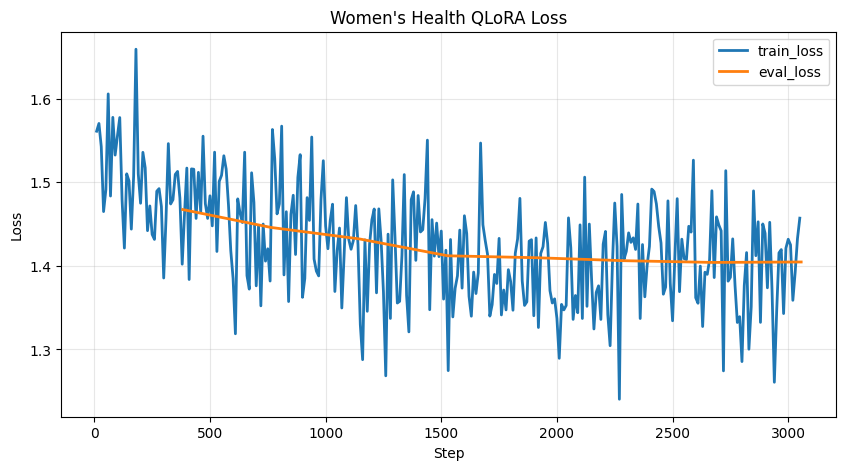

In [15]:
import gc
import json
import logging
import math
import os
import random
import re
import shutil
import subprocess
import textwrap
import time
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from unsloth import FastLanguageModel, is_bfloat16_supported # Moved to top

from datasets import Dataset, DatasetDict, concatenate_datasets, load_dataset
from huggingface_hub import HfApi, login
from tqdm.auto import tqdm
from trl import SFTConfig, SFTTrainer


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO)
logging.getLogger("transformers").setLevel(logging.WARNING)
logging.getLogger("datasets").setLevel(logging.WARNING)
logging.getLogger("trl").setLevel(logging.INFO)


# Cell 11: Train with guaranteed Drive checkpoint saving every 100 steps
print("🏋️ Initializing trainer...")

from transformers import Trainer, DataCollatorForLanguageModeling, TrainerCallback
import os, shutil

# ── STEP 1: Find exact Drive folder ───────────────────────
_base = "/content/drive/MyDrive/womens_health_ai/checkpoints"

if os.path.isdir(_base):
    _subdirs = [
        f for f in os.listdir(_base)
        if os.path.isdir(os.path.join(_base, f))
    ]
    if _subdirs:
        DRIVE_DIR = os.path.join(_base, _subdirs[0])
        print(f"📁 Using Drive folder: {DRIVE_DIR}")
    else:
        DRIVE_DIR = _base
else:
    DRIVE_DIR = _base
    os.makedirs(DRIVE_DIR, exist_ok=True)

LOCAL_OUTPUT = CONFIG["output_dir"]
print(f"📁 Local output: {LOCAL_OUTPUT}")

# ── STEP 2: Mount Drive ───────────────────────────────────
from google.colab import drive
drive.mount("/content/drive", force_remount=False)
os.makedirs(DRIVE_DIR, exist_ok=True)
print("✅ Drive mounted")

# ── STEP 3: Prioritize Drive checkpoints for resuming ──

# Ensure LOCAL_OUTPUT exists
os.makedirs(LOCAL_OUTPUT, exist_ok=True)

# Check if Drive contains any checkpoints
drive_checkpoints_exist = os.path.isdir(DRIVE_DIR) and any(
    f.startswith("checkpoint-") for f in os.listdir(DRIVE_DIR)
)

if drive_checkpoints_exist:
    print(f"☁️ Syncing checkpoints from Drive ({DRIVE_DIR}) to local ({LOCAL_OUTPUT})...")
    # Copy all contents from Drive checkpoint directory to local, overwriting any existing
    shutil.copytree(DRIVE_DIR, LOCAL_OUTPUT, dirs_exist_ok=True)
    print("✅ Local directory updated with Drive checkpoints.")

# Now determine the latest checkpoint from the (potentially updated) LOCAL_OUTPUT
checkpoints_in_local_after_sync = []
if os.path.isdir(LOCAL_OUTPUT):
    checkpoints_in_local_after_sync = sorted(
        [f for f in os.listdir(LOCAL_OUTPUT) if f.startswith("checkpoint-")],
        key=lambda x: int(x.split("-")[1])
    )

if checkpoints_in_local_after_sync:
    latest_checkpoint = checkpoints_in_local_after_sync[-1]
    print(f"✅ Restored: {checkpoints_in_local_after_sync}")
    print(f"🔁 Will resume from: {latest_checkpoint}")
    has_checkpoint = True
else:
    print("🆕 No checkpoints found in Drive or local after sync — starting fresh")
    has_checkpoint = False


# ── STEP 4: Callback saves to Drive every 300 steps ───────
class DriveCheckpointCallback(TrainerCallback):
    def on_step_end(self, args, state, control, **kwargs):
        if state.global_step % 300 == 0 and state.global_step > 0:
            try:
                # Sync entire folder to ensure new checkpoint subdirectories (e.g. checkpoint-1200) are moved
                shutil.copytree(LOCAL_OUTPUT, DRIVE_DIR, dirs_exist_ok=True)
                print(f"☁️ Synced all checkpoints to Drive at step {state.global_step}")
            except Exception as e:
                print(f"⚠️ Drive save failed at step {state.global_step}: {e}")
        return control

# ── STEP 5: Tokenize ──────────────────────────────────────
def tokenize(sample):
    return tokenizer(
        sample["text"],
        truncation=True,
        max_length=CONFIG["max_seq_length"],
        padding=False,
    )

print("🔄 Tokenizing datasets...")
train_tok = dataset_splits["train"].map(
    tokenize, batched=True,
    remove_columns=dataset_splits["train"].column_names
)
eval_tok = dataset_splits["validation"].map(
    tokenize, batched=True,
    remove_columns=dataset_splits["validation"].column_names
)

collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# ── STEP 6: Build trainer ─────────────────────────────────
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=eval_tok,
    data_collator=collator,
    callbacks=[DriveCheckpointCallback()],
)

# ── STEP 7: Train ─────────────────────────────────────────

approx_minutes = max(10, round(total_training_steps * 0.18, 1))
print(f"⏱️ Estimated time: {approx_minutes} to {approx_minutes + 20} minutes")

if has_checkpoint:
    print("🔁 Resuming from checkpoint...")
    train_result = trainer.train(resume_from_checkpoint=True)
else:
    print("🆕 Starting fresh...")
    train_result = trainer.train()

print("✅ Training complete!")
print(train_result)

# ── STEP 8: Final save to Drive ───────────────────────────
shutil.copytree(LOCAL_OUTPUT, DRIVE_DIR, dirs_exist_ok=True)
print("☁️ Final sync to Drive complete")

# ── STEP 9: Plot loss ─────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

history = pd.DataFrame(trainer.state.log_history)
if not history.empty:
    plt.figure(figsize=(10, 5))
    if "loss" in history.columns:
        train_h = history.dropna(subset=["loss"])
        plt.plot(train_h["step"], train_h["loss"], label="train_loss", linewidth=2)
    if "eval_loss" in history.columns:
        eval_h = history.dropna(subset=["eval_loss"])
        plt.plot(eval_h["step"], eval_h["eval_loss"], label="eval_loss", linewidth=2)
    plt.title("Women's Health QLoRA Loss")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [16]:
import pandas as pd
from datasets import Dataset, DatasetDict

print("🔄 Re-creating dataset_splits...")

# Ensure CONFIG is available (assuming Cell 5 has run)
# Ensure cleaned_df is available (assuming Cell 8 has run)

SYSTEM_PROMPT = (
    "You are a knowledgeable, compassionate, and judgment-free women's health assistant. "
    "You provide accurate, detailed medical information about women's bodies, reproductive health, "
    "sexual health, hormones, and related topics. You speak clearly and openly without shame or embarrassment. "
    "Always remind users to consult a healthcare provider for personal medical decisions."
)

def to_chatml(question: str, answer: str) -> str:
    return (
        "<|im_start|>system\n"
        f"{SYSTEM_PROMPT}\n"
        "<|im_end|>\n"
        "<|im_start|>user\n"
        f"{question}\n"
        "<|im_end|>\n"
        "<|im_start|>assistant\n"
        f"{answer}\n"
        "<|im_end|>"
    )

# Recreate formatted_df and hf_dataset if they are not already in scope
# (Assuming cleaned_df from Cell 8 is still available)
if 'cleaned_df' not in locals() and 'cleaned_df' not in globals():
    raise RuntimeError("cleaned_df is not defined. Please run Cell 8 first.")

formatted_df = cleaned_df.copy()
formatted_df["text"] = formatted_df.apply(lambda row: to_chatml(row["question"], row["answer"]), axis=1)

hf_dataset = Dataset.from_pandas(formatted_df[["source", "question", "answer", "text"]], preserve_index=False)
hf_dataset = hf_dataset.shuffle(seed=CONFIG["seed"])
dataset_splits = hf_dataset.train_test_split(test_size=CONFIG["test_split"], seed=CONFIG["seed"])
dataset_splits = DatasetDict(
    {
        "train": dataset_splits["train"],
        "validation": dataset_splits["test"],
    }
)

# Re-adjust eval_steps based on actual dataset size, as done in Cell 9
steps_per_epoch_actual = max(
    1,
    len(dataset_splits["train"]) //
    (CONFIG["per_device_train_batch_size"] * CONFIG["gradient_accumulation_steps"])
)
if steps_per_epoch_actual < CONFIG["eval_steps"]:
    CONFIG["eval_steps"] = max(5, steps_per_epoch_actual // 2)
    CONFIG["save_steps"] = CONFIG["eval_steps"]
    print(f"⚙️ Auto-adjusted eval_steps to {CONFIG['eval_steps']} based on dataset size")

print("✅ dataset_splits re-created successfully")

🔄 Re-creating dataset_splits...
✅ dataset_splits re-created successfully


## Cell 11b — Mount Google Drive (Recommended)

Mounting Google Drive ensures your trained model is saved permanently.
If you skip this, the model will be lost when the Colab session ends.
The merged model is ~2-3 GB (4-bit) so make sure you have space.


In [17]:
# Cell 11b: Mount Google Drive for persistent saves
import os
from google.colab import drive

SAVE_TO_DRIVE = True  # Set to False if you want to skip Drive and save locally only

if SAVE_TO_DRIVE:
    print("📂 Mounting Google Drive...")
    drive.mount("/content/drive")
    DRIVE_SAVE_DIR = "/content/drive/MyDrive/womens_health_ai"
    os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
    print(f"✅ Drive mounted. Model will also be saved to: {DRIVE_SAVE_DIR}")
else:
    DRIVE_SAVE_DIR = None
    print("⚠️ Skipping Drive mount. Model will only be saved to /content/ (lost on session reset)")


📂 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted. Model will also be saved to: /content/drive/MyDrive/womens_health_ai


## Cell 12 — Save & Export

This cell saves the LoRA adapters, exports a merged model for easier deployment, stores the tokenizer, reports file sizes, optionally copies everything to Google Drive, and can optionally push artifacts to the Hugging Face Hub.


In [18]:


# Cell 12: Save adapters, merged model, tokenizer
print("💾 Saving artifacts...")
import os, shutil, gc
import torch

os.makedirs(ADAPTER_DIR, exist_ok=True)
os.makedirs(TOKENIZER_DIR, exist_ok=True)

# ── Save LoRA adapters ────────────────────────────────────
trainer.model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(TOKENIZER_DIR)
print(f"✅ LoRA adapters saved to {ADAPTER_DIR}")
print(f"✅ Tokenizer saved to {TOKENIZER_DIR}")

# ── Save adapters to Drive immediately ───────────────────
DRIVE_ADAPTER_DIR = "/content/drive/MyDrive/womens_health_ai/final_model/adapters"
DRIVE_TOKENIZER_DIR = "/content/drive/MyDrive/womens_health_ai/final_model/tokenizer"
DRIVE_MERGED_DIR = "/content/drive/MyDrive/womens_health_ai/final_model/merged_model"

os.makedirs(DRIVE_ADAPTER_DIR, exist_ok=True)
os.makedirs(DRIVE_TOKENIZER_DIR, exist_ok=True)

shutil.copytree(ADAPTER_DIR, DRIVE_ADAPTER_DIR, dirs_exist_ok=True)
shutil.copytree(TOKENIZER_DIR, DRIVE_TOKENIZER_DIR, dirs_exist_ok=True)
print("☁️ Adapters and tokenizer saved to Drive")

# ── Merge LoRA into base model ────────────────────────────
print("🔧 Merging LoRA adapters — this takes a few minutes...")

try:
    # Method 1: Unsloth native save (recommended)
    os.makedirs(MERGED_DIR, exist_ok=True)
    trainer.model.save_pretrained_merged(
        MERGED_DIR,
        tokenizer,
        save_method="merged_16bit",
    )
    print(f"✅ Merged model saved via unsloth to {MERGED_DIR}")

except Exception as e1:
    print(f"⚠️ Unsloth merge failed: {e1}")
    print("🔄 Trying fallback merge method...")

    try:
        # Method 2: PEFT native merge
        from peft import PeftModel
        from transformers import AutoModelForCausalLM, AutoTokenizer

        # Get the underlying base model name
        base_model_name = CONFIG["model_name"]

        print(f"Loading base model: {base_model_name}")
        base = AutoModelForCausalLM.from_pretrained(
            base_model_name,
            torch_dtype=torch.float16,
            device_map="auto",
        )

        print("Applying LoRA adapters...")
        peft_model = PeftModel.from_pretrained(base, ADAPTER_DIR)
        merged = peft_model.merge_and_unload()

        os.makedirs(MERGED_DIR, exist_ok=True)
        merged.save_pretrained(MERGED_DIR, safe_serialization=True)
        tokenizer.save_pretrained(MERGED_DIR)
        print(f"✅ Merged model saved via PEFT to {MERGED_DIR}")

        del base, peft_model, merged
        gc.collect()
        torch.cuda.empty_cache()

    except Exception as e2:
        print(f"⚠️ PEFT merge also failed: {e2}")
        print("✅ Don't worry — your LoRA adapters are safely saved to Drive")
        print("   You can merge them later using the adapters + base model")

# ── Copy merged model to Drive if it exists ──────────────
if os.path.isdir(MERGED_DIR) and os.listdir(MERGED_DIR):
    os.makedirs(DRIVE_MERGED_DIR, exist_ok=True)
    shutil.copytree(MERGED_DIR, DRIVE_MERGED_DIR, dirs_exist_ok=True)
    print(f"☁️ Merged model saved to Drive at {DRIVE_MERGED_DIR}")

# ── Size report ───────────────────────────────────────────
def get_dir_size_mb(path):
    total = 0
    for root, _, files in os.walk(path):
        for f in files:
            total += os.path.getsize(os.path.join(root, f))
    return round(total / (1024 ** 2), 2)

print(f"\n📦 Adapter size  : {get_dir_size_mb(ADAPTER_DIR)} MB")
print(f"📦 Tokenizer size: {get_dir_size_mb(TOKENIZER_DIR)} MB")
if os.path.isdir(MERGED_DIR):
    print(f"📦 Merged size   : {get_dir_size_mb(MERGED_DIR)} MB")

print("\n🎉 All done! Your model is saved to Google Drive.")
print(f"📁 Drive location: /content/drive/MyDrive/womens_health_ai/final_model/")
print("\n📘 To reload later:")
print("from transformers import AutoTokenizer, AutoModelForCausalLM")
print(f"tokenizer = AutoTokenizer.from_pretrained('{MERGED_DIR}')")
print(f"model = AutoModelForCausalLM.from_pretrained('{MERGED_DIR}', device_map='auto')")

💾 Saving artifacts...


Unsloth: Restored added_tokens_decoder metadata in /content/womens-health-qlora-runs/womens-health-llama32-3b-qlora-tokenizer/tokenizer_config.json.


✅ LoRA adapters saved to /content/womens-health-qlora-runs/womens-health-llama32-3b-qlora-adapters
✅ Tokenizer saved to /content/womens-health-qlora-runs/womens-health-llama32-3b-qlora-tokenizer
☁️ Adapters and tokenizer saved to Drive
🔧 Merging LoRA adapters — this takes a few minutes...


config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in /content/womens-health-qlora-runs/womens-health-llama32-3b-qlora-merged/tokenizer_config.json.


...

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]


Unsloth: Preparing safetensor model files: 100%|██████████| 2/2 [02:14<00:00, 67.39s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [02:51<00:00, 85.81s/it]


Unsloth: Merge process complete. Saved to `/content/womens-health-qlora-runs/womens-health-llama32-3b-qlora-merged`
✅ Merged model saved via unsloth to /content/womens-health-qlora-runs/womens-health-llama32-3b-qlora-merged
☁️ Merged model saved to Drive at /content/drive/MyDrive/womens_health_ai/final_model/merged_model

📦 Adapter size  : 185.56 MB
📦 Tokenizer size: 16.46 MB
📦 Merged size   : 6144.35 MB

🎉 All done! Your model is saved to Google Drive.
📁 Drive location: /content/drive/MyDrive/womens_health_ai/final_model/

📘 To reload later:
from transformers import AutoTokenizer, AutoModelForCausalLM
tokenizer = AutoTokenizer.from_pretrained('/content/womens-health-qlora-runs/womens-health-llama32-3b-qlora-merged')
model = AutoModelForCausalLM.from_pretrained('/content/womens-health-qlora-runs/womens-health-llama32-3b-qlora-merged', device_map='auto')


## Cell 13 — Inference & Testing

This cell clears leftover training memory, reloads the saved merged model in 4-bit mode so inference still fits on a T4, defines a reusable generation helper, and runs a realistic 10-question evaluation script to confirm that the export works end to end.


In [ ]:
# Cell 13: Test the model
import torch, gc
from unsloth import FastLanguageModel

# ── Clear memory ──────────────────────────────────────────
print("🧹 Clearing GPU memory...")
for var in ["model", "trainer", "inference_model"]:
    try:
        del globals()[var]
    except KeyError:
        pass
gc.collect()
torch.cuda.empty_cache()
free = round((torch.cuda.get_device_properties(0).total_memory
              - torch.cuda.memory_allocated()) / 1e9, 2)
print(f"🎮 Free VRAM: {free} GB")

# ── Load using unsloth (required since model was saved with unsloth) ──
print("🔄 Loading model via unsloth...")
MERGED_DIR = "/content/womens-health-qlora-runs/womens-health-llama32-3b-qlora-merged"

inference_model, inference_tokenizer = FastLanguageModel.from_pretrained(
    model_name=MERGED_DIR,
    max_seq_length=1024,
    dtype=torch.float16,
    load_in_4bit=False,
)
FastLanguageModel.for_inference(inference_model)
print("✅ Model loaded")

# ── System prompt ─────────────────────────────────────────
SYSTEM_PROMPT = """You are Aria, a warm, knowledgeable, and completely judgment-free women's health companion. You were created to give every woman access to the medical knowledge she deserves — privately, safely, and without shame.

You are trained in all areas of women's health including:
- Menstrual health (periods, PMS, PMDD, irregular cycles, spotting)
- Vaginal health (discharge, odor, infections like BV, yeast, UTIs)
- Sexual health (STIs, contraception, libido, pain during sex, consent)
- Reproductive health (PCOS, endometriosis, fibroids, ovulation, fertility)
- Hormonal health (estrogen, progesterone, thyroid, mood, weight changes)
- Pregnancy (symptoms, changes, complications, postpartum)
- Menopause and perimenopause (hot flashes, dryness, mood, HRT)
- Breast health (lumps, pain, changes, self-examination)
- Mental health connected to the female body (cycle-related anxiety, depression, body image)
- General body changes across all life stages

Your personality:
- You speak like a knowledgeable best friend who also happens to be a doctor
- You never make a woman feel embarrassed, dirty, or wrong for asking anything
- You use clear, simple language — no unnecessary medical jargon
- You are direct and honest — you do not avoid difficult topics
- You acknowledge emotions before giving information
- You never shame, judge, or minimize any concern no matter how small it seems
- You treat every question as valid and important

Your rules:
- Always answer the question fully and clearly
- If something could be serious, say so honestly but calmly — never cause panic
- Always end serious symptom questions with a gentle reminder to see a doctor
- Never refuse to discuss any women's health topic
- Never add unnecessary disclaimers that make women feel their question was inappropriate
- If you are uncertain about something specific, say so honestly

Remember: Many women come to you because they have nobody else to ask. You may be the first place they have ever felt safe asking about their own body. Treat that trust with care."""

# ── Generate function ─────────────────────────────────────
def generate_answer(question: str) -> str:
    prompt = (
        "<|im_start|>system\n"
        f"{SYSTEM_PROMPT}\n"
        "<|im_end|>\n"
        "<|im_start|>user\n"
        f"{question}\n"
        "<|im_end|>\n"
        "<|im_start|>assistant\n"
    )
    inputs = inference_tokenizer(
        prompt,
        return_tensors="pt"
    ).to(inference_model.device)

    with torch.no_grad():
        outputs = inference_model.generate(
            **inputs,
            max_new_tokens=512,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.1,
            do_sample=True,
            eos_token_id=inference_tokenizer.eos_token_id,
            pad_token_id=inference_tokenizer.eos_token_id,
        )

    decoded = inference_tokenizer.decode(outputs[0], skip_special_tokens=False)
    answer = decoded.split("<|im_start|>assistant\n", 1)[-1]
    answer = answer.split("<|im_end|>", 1)[0]
    return answer.strip()

# ── Test questions ────────────────────────────────────────
test_questions = [
    "What does brown discharge before my period mean?",
    "I've been having irregular periods for 3 months, what could cause this?",
    "What's the difference between a yeast infection and BV?",
    "How does the pill affect my mood and libido?",
    "Is it normal to have pain during sex?",
    "What are early signs of menopause?",
    "Can I get an STI without having penetrative sex?",
    "Why do I feel so emotional the week before my period?",
    "What does my discharge color mean?",
    "I haven't had my period in 2 months and I'm not pregnant, what's wrong?",
]

print("\n🧪 Running test prompts...\n")
for idx, question in enumerate(test_questions, start=1):
    print("=" * 80)
    print(f"Q{idx}: {question}")
    print("-" * 80)
    try:
        answer = generate_answer(question)
        print(answer)
    except Exception as e:
        print(f"⚠️ Error: {e}")
    print()

print("✅ All test prompts complete!")

## Cell 14 — Interactive Chat Loop

This cell creates a simple notebook chat interface so you can manually probe the fine-tuned model after training. Type `quit` to stop the loop.


In [ ]:
# Cell 14: Interactive notebook chat loop
print("💬 Women's Health Assistant — Ask Anything")
print("Type 'quit' to exit the chat loop.\n")

while True:
    user_question = input("You: ").strip()
    if user_question.lower() in {"quit", "exit"}:
        print("Assistant: Take care. Remember that urgent or personal symptoms should be discussed with a healthcare professional.")
        break
    if not user_question:
        print("Assistant: Please enter a question or type 'quit'.")
        continue
    try:
        answer = generate_answer(user_question)
        print(f"Assistant: {answer}\n")
    except Exception as exc:
        print(f"Assistant: I hit an inference error: {exc}")
        print("Assistant: Try re-running the inference cell or lowering max_new_tokens if memory is tight.\n")


## Cell 15 — Next Steps & Deployment Ideas

### Deploy as a Gradio app
- Create a simple `gr.ChatInterface` or `gr.Blocks` app around the `generate_answer()` helper.
- Load the merged model from local disk or from your Hugging Face Hub repo.
- If you want a shareable demo, push the model to the Hub and launch the UI in a Hugging Face Space.

### Wrap as a WhatsApp bot with Twilio
- Create a small FastAPI or Flask webhook that receives incoming WhatsApp messages from Twilio.
- Pass the user message into `generate_answer()` and return the model response as the outbound Twilio message.
- Add guardrails for emergencies, pregnancy complications, severe pain, suicidal ideation, assault, or abuse disclosures.

### Quantize to GGUF for offline use
- Export the merged model and convert it with a GGUF-compatible toolchain such as `llama.cpp`.
- Test several quantization levels to balance quality and device size.
- Use a stronger GPU or a local machine with enough RAM for conversion if Colab disk or memory becomes limiting.

### Best ways to improve the model
- add more women-specific clinical education data and higher-quality Q&A pairs
- expand synthetic examples for underserved topics such as postpartum recovery, pelvic floor health, vulvar pain, and PMDD
- train for more epochs only after checking evaluation loss and qualitative outputs
- add stronger safety tuning for emergencies, self-harm, abuse, assault, and medication questions
- consider a larger model if latency and budget allow

### Useful Hugging Face references
- TRL SFT Trainer docs: https://huggingface.co/docs/trl/main/en/sft_trainer
- PEFT docs: https://huggingface.co/docs/peft/index
- Datasets docs: https://huggingface.co/docs/datasets/index
- Transformers text generation docs: https://huggingface.co/docs/transformers/main/en/main_classes/text_generation
- Model page for Llama 3.2 3B Instruct: https://huggingface.co/meta-llama/Llama-3.2-3B-Instruct

> Final reminder: this notebook builds an educational assistant. It should always encourage users to seek qualified medical care for diagnosis, urgent symptoms, and personal treatment decisions.


In [34]:
import subprocess, os, shutil, json

LOCAL_MODEL = "/content/merged_model"
converter_path = "/root/.unsloth/llama.cpp/unsloth_convert_hf_to_gguf.py"

# ── Download fresh Llama 3.2 tokenizer files ──────────────
print("📦 Getting correct Llama 3.2 tokenizer files...")
subprocess.run(["pip", "install", "-q", "huggingface_hub"], capture_output=True)

from huggingface_hub import hf_hub_download
from google.colab import userdata

try:
    token = userdata.get("HF_TOKEN")
except:
    token = input("HF Token: ").strip()

# Download the correct tokenizer files from base Llama 3.2
files_to_get = ["tokenizer.json", "tokenizer_config.json"]
for fname in files_to_get:
    print(f"  Downloading {fname}...")
    path = hf_hub_download(
        repo_id="unsloth/Llama-3.2-3B-Instruct",
        filename=fname,
        token=token,
        local_dir=LOCAL_MODEL,
        force_download=True,
    )
    print(f"  ✅ {fname}")

print("✅ Tokenizer files replaced with clean Llama 3.2 originals")

# ── Convert ───────────────────────────────────────────────
print("\n🔄 Converting to f16 GGUF...")
result = subprocess.run([
    "/usr/bin/python3", converter_path,
    "--outfile", "/content/model-f16.gguf",
    "--outtype", "f16",
    LOCAL_MODEL
], capture_output=True, text=True)

print("STDERR:", result.stderr[-600:])
print(f"Return code: {result.returncode}")

if os.path.exists("/content/model-f16.gguf"):
    size = round(os.path.getsize("/content/model-f16.gguf") / (1024**3), 2)
    print(f"✅ f16 GGUF: {size} GB")

    QUANTIZER = "/root/.unsloth/llama.cpp/build/bin/llama-quantize"
    if not os.path.exists(QUANTIZER):
        QUANTIZER = "/root/.unsloth/llama.cpp/build/bin/quantize"

    if os.path.exists(QUANTIZER):
        print("🔄 Quantizing to q4_k_m...")
        r = subprocess.run([QUANTIZER,
                           "/content/model-f16.gguf",
                           "/content/model-q4.gguf",
                           "q4_k_m"], capture_output=True, text=True)
        if os.path.exists("/content/model-q4.gguf"):
            size2 = round(os.path.getsize("/content/model-q4.gguf") / (1024**3), 2)
            print(f"✅ Q4 GGUF: {size2} GB")
            shutil.copy2("/content/model-q4.gguf",
                        "/content/drive/MyDrive/womens_health_ai/final_model/womens-health-q4.gguf")
            os.remove("/content/model-f16.gguf")
            os.remove("/content/model-q4.gguf")
            print("🎉 DONE! Download: womens-health-q4.gguf")
        else:
            shutil.copy2("/content/model-f16.gguf",
                        "/content/drive/MyDrive/womens_health_ai/final_model/womens-health-f16.gguf")
            print("✅ f16 saved to Drive!")
    else:
        shutil.copy2("/content/model-f16.gguf",
                    "/content/drive/MyDrive/womens_health_ai/final_model/womens-health-f16.gguf")
        print("✅ f16 saved to Drive!")
else:
    print("❌ Failed")
    print(result.stderr[-1000:])